# Paper figures

Every figure of the paper that rests on device data, redrawn from the data in this repository. Each
section says which runs it uses, where they are stored (`data/results/<backend>/<structure>/<kind>/`), and
how they were analysed. The PDFs go to `figures/paper_figures/`.

All data is in this package's result format, whether it was taken with this package or converted from
earlier campaigns by `scripts/import_legacy_chains.py` and `scripts/import_legacy_codes.py`. For every result, $r$ and its shot-noise error
are recomputed from the stored samples, the noiseless reference $r_{\rm ideal}$ is exact, and the
random baseline is exact: $r_{\rm rand} = 1/2$, with shot-noise spread $\sigma_{\rm rand} = 1/(2\sqrt{(n-1)S})$
for $S$ shots. The runs are named explicitly, so adding a campaign to `data/` never changes a published
figure by accident.

| figure | what it shows | section |
|---|---|---|
| Fig. 2c | the chip with the ground the scan covers, and two placements of the surface code $d = 3$ drawn out | 11 |
| Fig. 3c | distribution of $r$ over every data-ancilla-data triplet, per device, at $p = 3$ | 1 |
| Fig. 3d | median $r$ (bars: inter-quartile range) over the triplets, against depth | 2 |
| Fig. 3e | $r$ against depth for each device's best triplet, with Helios-1E | 3 |
| Fig. 3f | the same triplets as $r_{\rm ovl}$, with points indistinguishable from random marked | 4 |
| Fig. 4 | effective error per edge $\lambda_{\rm eff}$ against chain length: Helios-1 (serialized runs up to 25 August, parallel from 9 September) and IBM Boston | 5 |
| Fig. 5a | depolarizing simulation: overlap collapse per chain length, $\kappa_r = \kappa_0/N_q$ | 6 |
| Fig. 5b | $\lambda_{\rm eff}$ of a 10-spin chain on IBM Boston and the Helios-1E emulator, direct and MCM | 6 |
| Fig. 5c | $\lambda_{\rm eff}$ against $N_q$ for eight devices, direct and MCM | 6 |
| Fig. 5d | mean MCM $\lambda_{\rm eff}$ of eight devices against their release date | 6 |
| Fig. 6 | $r$ at each structure's best depth against its number of data qubits, for every code family and QPU that ran one | 7 |
| Fig. 7a | shots a noiseless device needs to separate LR-QAOA from random guessing, surface code $d = 3, 5$ | 8 |
| Fig. 7b | the same for the BB qLDPC codes BB18, BB24, BB30 | 8 |
| Fig. 8a | shots per device to rank two devices a factor of two apart in error rate, against depth | 9 |
| Fig. 8b, 8c | MCM $r$ of the surface code $d = 3, 5$ on H2-1, Helios-1, IBM Phoenix and the emulators, with the noiseless curve and the random limit | 9 |
| Fig. 9 | LR-QAOA $r_{\rm ovl}$ against the decoded logical error rate of a surface-code memory on the same patch, per patch of an `ibm_phoenix` position scan | 10 |

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))          # not needed after `pip install -e .`
RESULTS = ROOT / "data" / "results"
FIGURES = ROOT / "figures" / "paper_figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from qecbench import Chain
from qecbench.analysis import load_results
from qecbench.lrqaoa import ideal_r, random_baseline

mpl.rcParams.update({
    "xtick.labelsize": 16, "ytick.labelsize": 16, "font.size": 16, "axes.linewidth": 2,
    "axes.titlesize": 16, "axes.labelsize": 16, "lines.linewidth": 2.2, "lines.markersize": 3,
    "lines.markeredgewidth": 1.2, "errorbar.capsize": 3, "legend.fontsize": 14,
    "xtick.major.width": 3, "xtick.major.size": 10, "ytick.major.width": 3, "ytick.major.size": 8,
    "xtick.minor.width": 1.5, "xtick.minor.size": 6, "ytick.minor.width": 1.5, "ytick.minor.size": 6,
    "mathtext.fontset": "dejavusans", "font.family": "sans-serif",
})
%matplotlib inline
SHOW_LABELS = False                    # the paper panels have no axis labels or legends; True adds them


def runs(backend, stamps, kind="mcm", structure="chain", **kwargs):
    # results of the named run files only: <stamp>_<backend>_<structure>_<kind>.json
    files = {f"{stamp}_{backend}_{structure}_{kind}.json" for stamp in stamps}
    return load_results(RESULTS, backend, kind=kind, files=files, **kwargs)


TRIPLET = Chain((0, 1, 2))             # any triplet: the references depend only on the Hamiltonian


def noiseless(p):
    return ideal_r(TRIPLET, int(p))


def random_sigma(shots):
    return random_baseline(TRIPLET, shots)[1]

### Data shared by Fig. 3c-3f

**Triplet campaigns.** One campaign per device, 500 shots per circuit, every data-ancilla-data triplet the
device offers, at $p = 3, 6, 9, 12$. Converted from the earlier triplet files
(`<stamp>_<backend>_tri_<d1>_<a>_<d2>_mcm_nq2_depth<p>.json`) into
`data/results/<backend>/chain/mcm/`:

| device | run file(s) | triplets |
|---|---|---|
| `iqm_garnet` | `20260813_0729_iqm_garnet_chain_mcm.json` | 35 |
| `iqm_emerald` | `20260813_0722_…`, `20260813_0723_iqm_emerald_chain_mcm.json` | 104 |
| `ibm_kingston` | `20260813_1637_ibm_kingston_chain_mcm.json` | 148 |
| `ibm_boston` | `20260814_0818_ibm_boston_chain_mcm.json` | 148 |
| `ibm_phoenix` | `20260902_1629_ibm_phoenix_chain_mcm.json` | 120 |

Later campaigns on Boston (11 September) and Phoenix (9 and 11 September) are not part of these figures.

**Helios-1E two-spin runs** (Fig. 3e, 3f). The same two-spin MCM circuit on Quantinuum's **Helios-1E
emulator** (24 February 2026), 500 shots at $p = 3, 5, 7, 10, 12$, one file per depth. Its logical labels are
data qubits 0, 1 and ancilla 2. The files, in the older MaxCut schema (for one edge the cut ratio equals
$r$), are converted into `data/results/Helios-1E/chain/mcm/20260224_{153017,153157,153300,153359,154357}_Helios-1E_chain_mcm.json`
and flagged as simulated.

**One difference from the first versions of these figures.** The values of $r$, the medians, the quartiles
and the noiseless curves are unchanged. The random reference is now the exact baseline, $1/2 \pm 3 \cdot 1/(2\sqrt{500})$,
instead of a bootstrap estimate ($0.506 \pm 3 \cdot 0.020$). The grey bands are therefore centred on $1/2$ and
slightly wider.

In [3]:
TRIPLET_RUNS = {                       # the order used in every panel
    "iqm_garnet":   ["20260813_0729"],
    "iqm_emerald":  ["20260813_0722", "20260813_0723"],
    "ibm_kingston": ["20260813_1637"],
    "ibm_boston":   ["20260814_0818"],
    "ibm_phoenix":  ["20260902_1629"],
}
HELIOS_PAIR_RUNS = {"Helios-1E": ["20260224_153017", "20260224_153157", "20260224_153300",
                                  "20260224_153359", "20260224_154357"]}
COLOURS = {"iqm_garnet": "#3b6fd4", "iqm_emerald": "#c4c43f", "ibm_kingston": "#8a4bc9",
           "ibm_boston": "#b8560f", "ibm_phoenix": "#2a9d8f", "Helios-1E": "#0f9b8e"}

# {device: {triplet: {p: summary}}}; summary holds r, r_err, r_ideal, r_ovl, r_rand, r_rand_std, shots
sweeps = {device: runs(device, stamps, kind="mcm", n_data=2) for device, stamps in {**TRIPLET_RUNS, **HELIOS_PAIR_RUNS}.items()}
for device, per_triplet in sweeps.items():
    depths = sorted({p for by in per_triplet.values() for p in by})
    shots = sorted({s["shots"] for by in per_triplet.values() for s in by.values()})
    print(f"{device:>13}: {len(per_triplet):>3} triplet(s), depths {depths}, shots {shots}")

   iqm_garnet:  35 triplet(s), depths [3, 6, 9, 12], shots [500]
  iqm_emerald: 104 triplet(s), depths [3, 6, 9, 12], shots [500]
 ibm_kingston: 148 triplet(s), depths [3, 6, 9, 12], shots [500]
   ibm_boston: 148 triplet(s), depths [3, 6, 9, 12], shots [500]
  ibm_phoenix: 120 triplet(s), depths [3, 6, 9, 12], shots [500]
    Helios-1E:   1 triplet(s), depths [3, 5, 7, 10, 12], shots [500]


## 1. Fig. 3c - approximation ratio of every triplet, per device

**What it shows.** Each device's mid-circuit-measurement cycle, tested on every data-ancilla-data triplet
`(d1, a, d2)` of the chip: a two-spin LR-QAOA of depth $p = 3$ whose $ZZ$ term runs through the ancilla, its
mid-circuit measurement and the feed-forward. One row per device, from top to bottom: IQM Garnet, IQM
Emerald, IBM Kingston, IBM Boston, IBM Phoenix. Each point is one triplet. The shaded violin is the
distribution, the bar under it the inter-quartile range, and the circle the median. The dashed line is the
noiseless $r_{\rm ideal}(p=3)$, and the grey band is random guessing, $r_{\rm rand} \pm 3\sigma_{\rm rand}$. A device
whose triplets sit close to the dashed line runs the cycle well on every qubit, and the width of its row
is how uneven the chip is.

/var/folders/76/d4kyjysx1xgdrrs6zzs63s180000gn/T/ipykernel_90698/1975640055.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  for body in ax.violinplot([v], positions=[y], vert=False, widths=0.8, showextrema=False,


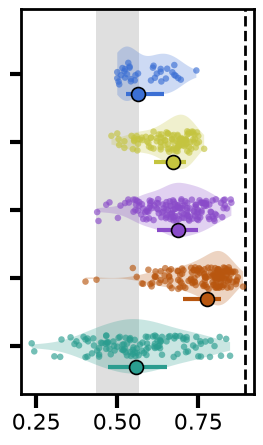

p = 3, 500 shots: r_ideal = 0.895, random band 0.500 ± 0.067 (3 sigma)
    iqm_garnet: n= 35  median 0.564  IQR [0.527, 0.643]  range [0.500, 0.744]
   iqm_emerald: n=104  median 0.672  IQR [0.612, 0.710]  range [0.482, 0.768]
  ibm_kingston: n=148  median 0.686  IQR [0.622, 0.748]  range [0.438, 0.852]
    ibm_boston: n=148  median 0.778  IQR [0.703, 0.821]  range [0.402, 0.888]
   ibm_phoenix: n=120  median 0.558  IQR [0.471, 0.653]  range [0.236, 0.848]


In [4]:
DEPTH_3C = 3
triplet_r = {d: np.array(sorted(by[DEPTH_3C]["r"] for by in sweeps[d].values() if DEPTH_3C in by)) for d in TRIPLET_RUNS}
S = sweeps["ibm_boston"][next(iter(sweeps["ibm_boston"]))][DEPTH_3C]["shots"]
sigma = random_sigma(S)

fig, ax = plt.subplots(figsize=(3, 5))
rng = np.random.default_rng(0)
rows = list(TRIPLET_RUNS)[::-1]        # first device on top
for y, device in enumerate(rows):
    v, colour = triplet_r[device], COLOURS[device]
    for body in ax.violinplot([v], positions=[y], vert=False, widths=0.8, showextrema=False,
                              showmedians=False)["bodies"]:
        body.set_facecolor(colour); body.set_alpha(0.25); body.set_edgecolor("none")
    ax.scatter(v, y + rng.uniform(-0.16, 0.16, v.size), s=22, color=colour, alpha=0.65, edgecolors="none", zorder=3)
    q1, med, q3 = np.quantile(v, [0.25, 0.5, 0.75])
    ax.plot([q1, q3], [y - 0.3] * 2, color=colour, lw=3, solid_capstyle="butt", zorder=4)
    ax.plot([med], [y - 0.3], marker="o", ms=10, color=colour, zorder=5, markeredgecolor="black")
ax.axvspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.25, lw=0, zorder=0)
ax.axvline(noiseless(DEPTH_3C), ls="--", lw=2, color="black", zorder=1)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([d.replace("_", " ") for d in rows] if SHOW_LABELS else [""] * len(rows))
ax.set_ylim(-0.7, len(rows) - 0.05)
if SHOW_LABELS:
    ax.set_xlabel("approximation ratio $r$")
fig.savefig(FIGURES / f"fig3c_mcm_r_distribution_p{DEPTH_3C}.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"p = {DEPTH_3C}, {S} shots: r_ideal = {noiseless(DEPTH_3C):.3f}, random band 0.500 ± {3 * sigma:.3f} (3 sigma)")
for device, v in triplet_r.items():
    print(f"{device:>14}: n={len(v):>3}  median {np.median(v):.3f}  IQR [{np.quantile(v, .25):.3f}, "
          f"{np.quantile(v, .75):.3f}]  range [{v.min():.3f}, {v.max():.3f}]")

## 2. Fig. 3d - approximation ratio against depth, over all triplets

**What it shows.** For each device, the median $r$ over all its triplets at $p = 3, 6, 9, 12$, with the
inter-quartile range as error bars (a small horizontal offset keeps the devices apart). The dashed line is
the noiseless $r_{\rm ideal}(p)$, which rises with depth, and the grey band is random guessing. On a perfect
device the points would follow the dashed line upwards. The gap to it, and whether it grows with $p$, is
the accumulated cost of one more measure-and-correct cycle per layer.

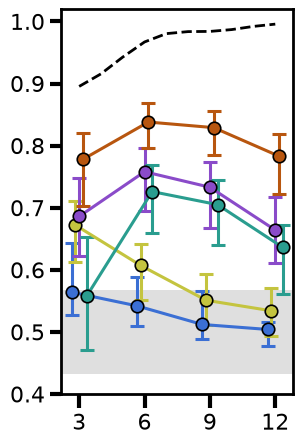

        device                p=3                p=6                p=9               p=12
    iqm_garnet    0.564 -0.037+0.079    0.542 -0.032+0.046    0.512 -0.024+0.054    0.504 -0.027+0.012
   iqm_emerald    0.672 -0.060+0.038    0.607 -0.055+0.034    0.551 -0.039+0.043    0.534 -0.040+0.036
  ibm_kingston    0.686 -0.064+0.062    0.758 -0.063+0.038    0.733 -0.066+0.041    0.664 -0.053+0.052
    ibm_boston    0.778 -0.075+0.042    0.838 -0.042+0.030    0.829 -0.044+0.027    0.783 -0.061+0.035
   ibm_phoenix    0.558 -0.087+0.095    0.726 -0.067+0.042    0.705 -0.066+0.039    0.636 -0.075+0.036


In [5]:
DEPTHS_3D = [3, 6, 9, 12]
stats = {}
for device in TRIPLET_RUNS:
    for p in DEPTHS_3D:
        v = np.array([by[p]["r"] for by in sweeps[device].values() if p in by])
        q1, mid, q3 = np.quantile(v, [0.25, 0.5, 0.75])
        stats.setdefault(device, []).append((p, mid, mid - q1, q3 - mid, len(v)))

fig, ax = plt.subplots(figsize=(3, 5))
ax.axhspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.25, lw=0, zorder=0, label="random $3\\sigma$")
fine = np.arange(min(DEPTHS_3D), max(DEPTHS_3D) + 1)
ax.plot(fine, [noiseless(p) for p in fine], ls="--", lw=2, color="black", zorder=1, label="noiseless")
for dx, device in zip(np.linspace(-0.35, 0.35, len(TRIPLET_RUNS)), TRIPLET_RUNS):
    p, mid, lo, hi, n = np.array(stats[device]).T
    ax.errorbar(p + dx, mid, yerr=[lo, hi], color=COLOURS[device], lw=2.2, marker="o", ms=9,
                markeredgecolor="black", capsize=5, capthick=2.2, elinewidth=2.2, zorder=3,
                label=device.replace("_", " "))
ax.set_xticks(DEPTHS_3D)
ax.set_ylim(0.4, 1.02)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel="approximation ratio $r$")
    ax.legend(fontsize=10, loc="upper center", bbox_to_anchor=(0.5, 1.4), ncol=2)
fig.savefig(FIGURES / "fig3d_mcm_r_vs_p_median.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"{'device':>14} " + " ".join(f"{'p=' + str(p):>18}" for p in DEPTHS_3D))
for device in TRIPLET_RUNS:
    print(f"{device:>14} " + " ".join(f"{mid:>8.3f} -{lo:.3f}+{hi:.3f}" for _, mid, lo, hi, _ in stats[device]))

## 3. Fig. 3e - the best triplet of each device, against depth

**What it shows.** Fig. 3c-3d describe whole chips. This panel asks how good the gadget can be at all: one
curve per device for its single best triplet, and the same circuit on Quantinuum's Helios-1E emulator, where
the ancilla is allocated freely on an all-to-all machine, for scale. The dashed line is the noiseless
$r_{\rm ideal}(p)$ and the grey band random guessing.

**Which triplet is "best".** The one with the highest $r_{\rm ovl}$ at $p = 3$, among triplets measured at
three or more depths. Its whole sweep is then drawn. Choosing by one depth is a statement about that depth:
the winners sit well above their device's median, but the ranking over the full sweep can differ (on
Boston, the $p = 3$ winner is not the best triplet over all depths). The table below gives each winner's
shot-noise uncertainty and how many other triplets are within it (`ties`). Where `ties` is not zero, the
choice of winner is not resolved at 500 shots.

Devices shown: Helios-1E, IQM Garnet, IQM Emerald, IBM Kingston and IBM Boston, as in the published panel.
IBM Phoenix was measured after that panel was made; add it to `FIG3EF_DEVICES` to include it.

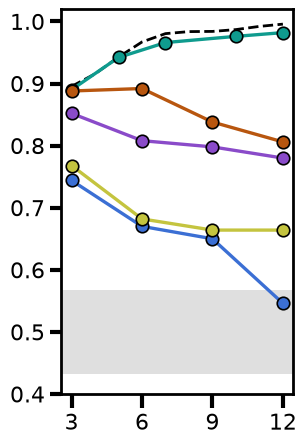

best triplet = highest r_ovl at p = 3

       device  triplet (d1, a, d2)  r_ovl  sigma  ties   r by depth
    Helios-1E            (0, 2, 1)  0.986  0.035     0   p3=0.890  p5=0.942  p7=0.966  p10=0.976  p12=0.982
   iqm_garnet         (15, 14, 18)  0.617  0.049     0   p3=0.744  p6=0.670  p9=0.650  p12=0.546
  iqm_emerald         (35, 34, 42)  0.678  0.048     2   p3=0.768  p6=0.682  p9=0.664  p12=0.664
 ibm_kingston      (147, 148, 149)  0.890  0.040     2   p3=0.852  p6=0.808  p9=0.798  p12=0.780
   ibm_boston      (136, 143, 142)  0.981  0.036     0   p3=0.888  p6=0.892  p9=0.838  p12=0.806


In [6]:
FIG3EF_DEVICES = ["Helios-1E", "iqm_garnet", "iqm_emerald", "ibm_kingston", "ibm_boston"]
SCORE_DEPTH = 3


def score(by):
    s = by[SCORE_DEPTH]
    return s["r_ovl"], np.sqrt(s["r"] * (1 - s["r"]) / s["shots"]) / (s["r_ideal"] - 0.5)


best = {}
for device in FIG3EF_DEVICES:
    candidates = sorted(((score(by)[0], chain.qubits, chain) for chain, by in sweeps[device].items()
                         if SCORE_DEPTH in by and len(by) >= 3), reverse=True)
    value, _, chain = candidates[0]
    sigma_score = score(sweeps[device][chain])[1]
    ties = sum(1 for other, _, _ in candidates[1:] if other > value - sigma_score)
    best[device] = dict(chain=chain, by=sweeps[device][chain], score=value, sigma=sigma_score, ties=ties)

fig, ax = plt.subplots(figsize=(3, 5))
all_p = sorted({p for b in best.values() for p in b["by"]})
fine = np.arange(min(all_p), max(all_p) + 1)
ax.plot(fine, [noiseless(p) for p in fine], "--", lw=2, color="black", zorder=2, label="noiseless")
ax.axhspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.25, lw=0, zorder=0, label="random $3\\sigma$")
for device, b in best.items():
    ps = sorted(b["by"])
    ax.plot(ps, [b["by"][p]["r"] for p in ps], "o-", ms=9, lw=2.4, markeredgecolor="black",
            color=COLOURS[device], zorder=3, label=device.replace("_", " "))
ax.set_xticks([3, 6, 9, 12])
ax.set_ylim(0.4, 1.02)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel="approximation ratio $r$")
    ax.legend(fontsize=10, loc="lower left")
fig.savefig(FIGURES / "fig3e_mcm_best_triplet_r.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"best triplet = highest r_ovl at p = {SCORE_DEPTH}\n")
print(f"{'device':>13} {'triplet (d1, a, d2)':>20} {'r_ovl':>6} {'sigma':>6} {'ties':>5}   r by depth")
for device, b in best.items():
    print(f"{device:>13} {str(b['chain'].qubits):>20} {b['score']:>6.3f} {b['sigma']:>6.3f} {b['ties']:>5}   "
          + "  ".join(f"p{p}={b['by'][p]['r']:.3f}" for p in sorted(b["by"])))

## 4. Fig. 3f - the best triplets as normalised quality

**What it shows.** The triplets of Fig. 3e as $r_{\rm ovl} = (r - r_{\rm rand})/(r_{\rm ideal} - r_{\rm rand})$, which
divides out the ramp: a noiseless device sits on the dashed line at 1 at every depth, and 0 is random
guessing. The decay of each curve is what the measure-and-correct cycle costs as layers accumulate.

**Significance.** A point is drawn as a filled circle only if $r > r_{\rm rand} + 3\sigma_{\rm rand}$ for that run's
shots, i.e. significantly better than random sampling. A point that fails this is drawn as an ✕ on a dashed
continuation, so the sweep stays visible without being read as a measurement. The grey region is the
same threshold in $r_{\rm ovl}$ units, $3\sigma_{\rm rand} / (r_{\rm ideal}(p) - 1/2)$, which shrinks with depth as
$r_{\rm ideal}$ grows. Anything inside it cannot be told apart from random.

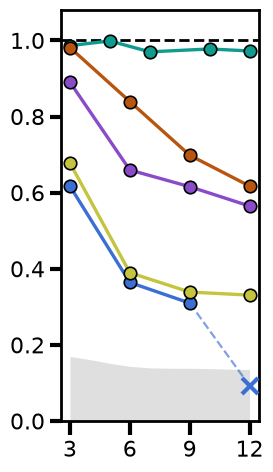

✕ iqm_garnet p=12: r = 0.546 <= random + 3 sigma = 0.567 (drawn, but not a measurement)
random threshold: r > 0.567; in r_ovl 0.170 at p=3 down to 0.135 at p=12


In [7]:
fig, ax = plt.subplots(figsize=(3, 5))
failed = []
for device, b in best.items():
    colour, ps = COLOURS[device], sorted(b["by"])
    ys = np.array([b["by"][p]["r_ovl"] for p in ps])
    ok = np.array([b["by"][p]["r"] > 0.5 + 3 * random_sigma(b["by"][p]["shots"]) for p in ps])
    failed += [(device, p, b["by"][p]["r"], 0.5 + 3 * random_sigma(b["by"][p]["shots"]))
               for p, passed in zip(ps, ok) if not passed]
    ps = np.array(ps)
    if not ok.all():
        ax.plot(ps, ys, "--", lw=1.6, alpha=0.65, color=colour, zorder=2)
    ax.plot(ps[ok], ys[ok], "o-", ms=9, lw=2.4, markeredgecolor="black", color=colour, zorder=3,
            label=device.replace("_", " "))
    ax.plot(ps[~ok], ys[~ok], "x", ms=11, mew=3, color=colour, zorder=4)

fine = np.arange(3, 13)
threshold = 3 * sigma / (np.array([noiseless(p) for p in fine]) - 0.5)
ax.fill_between(fine, 0, threshold, color="gray", alpha=0.25, lw=0, zorder=0)
ax.axhline(1.0, ls="--", lw=2, color="black", zorder=1)
ax.set_xticks([3, 6, 9, 12])
ax.set_ylim(0, 1.08)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel=r"$r_{\rm ovl}$")
    ax.legend(fontsize=10, loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES / "fig3f_mcm_best_triplet_rovl.pdf", transparent=True, bbox_inches="tight")
plt.show()

for device, p, r, limit in failed:
    print(f"✕ {device} p={p}: r = {r:.3f} <= random + 3 sigma = {limit:.3f} (drawn, but not a measurement)")
print(f"random threshold: r > {0.5 + 3 * sigma:.3f}; in r_ovl {threshold[0]:.3f} at p=3 down to {threshold[-1]:.3f} at p=12")

## 5. Fig. 4 - effective error per edge against chain length: Helios-1 and IBM Boston

**What it shows.** For MCM chains of $N_q$ spins, the effective error per edge $\lambda_{\rm eff}$: the two-qubit
depolarizing strength per edge interaction that reproduces the measured decay,

$$r_{\rm ovl}(p) = 2^{-(\kappa_0/N_q)\,(N_q-1)\,p\,\lambda_{\rm eff}} ,$$

with $\kappa_0$ from the depolarizing simulation of `noise_study.ipynb` (`data/noise_study/kappa_fits.json`).
Squares are Helios-1 hardware (50 shots), circles IBM Boston (1000 shots). Lower is better. A flat curve means
each edge costs the same however long the chain, and a rising one means longer chains cost more per edge.

**Why the serialized Helios-1 runs are worse.** Every Helios-1 run before September (grey: 9 March at
$N_q = 40$, 25 May at $N_q = 30$, 26 May at $N_q = 50$; purple: 25 August at $N_q = 30, 40, 50$) built each layer
with the serial program `qaoa_mcm`. It emits the $N_q - 1$ gadgets bond by bond, and gadget $i+1$ shares a data
qubit with gadget $i$, so it has to wait for gadget $i$'s measurement and correction. A layer is then a chain of
$N_q - 1$ dependent measure-and-correct steps. The data qubits sit idle through all of them, so the memory error
per layer grows with the chain length, and the fit charges it to every edge. The 9 September runs (orange) use
the parallel program `qaoa_mcm_parallel` (the program `benchmark_quantinuum.ipynb` submits in this repository).
It runs the even bonds, then the odd bonds, with the gadgets of a class on disjoint qubits, so none waits on its
neighbour, and at most 8 run at once in Helios-1's operation zones.

The 25 August and 9 September campaigns run the same chains, depths and shots, two weeks apart, so the step
between them isolates the ordering: $\lambda_{\rm eff}$ drops 3.1x, 2.5x and 3.4x at $N_q = 30, 40, 50$ (printed
below). The grey curve is serialized too, so the further ~2x between it and 25 August (1.9x, 1.9x, 2.3x) is not
the ordering. Those runs are three to five months apart, and the gap most likely reflects improvements in the
machine's calibration over that time (no calibration record of these runs is kept to confirm it).

*Provenance of the orderings.* The serial program is the one the earlier Quantinuum campaign used for the May
runs. The 25 August runs were serialized as well; their earlier fit files record them as "colour?", which is wrong.
The parallel program was introduced on 1 September. The 9 September runs are recorded as the two-colour ordering, and the
15 September run is known to use it.

**IBM Boston.** On 25 August each size used its own layout chosen at submission. The 27 and 31 August
campaigns are pinned to the same chain of physical qubits, so the gap between them is run-to-run
repeatability. All three use the two-colour ordering.

**Fits.** Helios-1 over $p = 3, 5, 10$ (all it ran), Boston over $p = 10\ldots50$, where its decay is closest to
a pure exponential. Each device is therefore compared only with itself. Points at or below random are
dropped. Fitted values only, no error bars: with 3-6 points per fit the curve-fit covariance reflects the
number of points more than the measurement.

| series | runs in `data/results/<backend>/chain/mcm/` |
|---|---|
| Helios-1, earlier (serial) | `20260309_0726` ($N_q = 40$, 20 shots), `20260525_0955` (30), `20260526_0735` (50) |
| Helios-1, 08-25 (serial) | `20260825_1505` (30), `20260825_1540` + `_1541` (40), `20260825_1542` + `_1543` + `_1606` (50) |
| Helios-1, 09-09 (parallel) | `20260909_1423` (30), `20260909_1509` (40), `20260909_1521` (50) |
| ibm_boston, 08-25 | `20260825_1618` (10), `_1619` (20), `_1620` (30, 40), `_1621` (50), `_1629` (60) |
| ibm_boston, 08-27 | `20260827_1035` ($N_q = 10\ldots60$) |
| ibm_boston, 08-31 | `20260831_1122` ($N_q = 10\ldots60$) |

**Difference from the first version of the figure.** Every $\lambda_{\rm eff}$ is 0.95x the published value,
the ratio of the two $\kappa_0$: 3.69 from the per-edge simulation here, against 3.51 fitted earlier with a
per-CNOT error. The references are exact here, and at these sizes that moves no value by more than 2%.
The shapes and the ordering of the curves are unchanged.

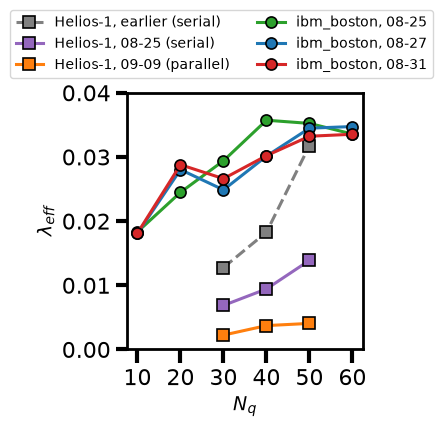

kappa_0 = 3.689; lambda_eff per edge

                                     10         20         30         40         50         60
Helios-1, earlier (serial)            -          -  1.277e-02  1.827e-02  3.179e-02          -
Helios-1, 08-25 (serial)              -          -  6.867e-03  9.432e-03  1.389e-02          -
Helios-1, 09-09 (parallel)            -          -  2.242e-03  3.721e-03  4.063e-03          -
ibm_boston, 08-25             1.833e-02  2.449e-02  2.941e-02  3.573e-02  3.523e-02  3.357e-02
ibm_boston, 08-27             1.809e-02  2.803e-02  2.487e-02  3.013e-02  3.449e-02  3.474e-02
ibm_boston, 08-31             1.814e-02  2.879e-02  2.662e-02  3.020e-02  3.323e-02  3.354e-02

Helios-1, earlier (serial)   grows 2.5x from N_q = 30 to 50
Helios-1, 08-25 (serial)     grows 2.0x from N_q = 30 to 50
Helios-1, 09-09 (parallel)   grows 1.8x from N_q = 30 to 50
ibm_boston, 08-25            grows 1.8x from N_q = 10 to 60
ibm_boston, 08-27            grows 1.9x from N_q = 10 to

In [8]:
import json

from qecbench.noise_study import fit_lambda_eff

KAPPA_0 = json.loads((ROOT / "data" / "noise_study" / "kappa_fits.json").read_text())["kappa_0"]["value"]
HELIOS_WINDOW, BOSTON_WINDOW = [3, 5, 10], [10, 15, 20, 30, 40, 50]
FIG4_SERIES = [   # legend, backend, run stamps, fit window, colour, marker, linestyle
    ("Helios-1, earlier (serial)", "Helios-1", ["20260309_0726", "20260525_0955", "20260526_0735"],
     HELIOS_WINDOW, "grey", "s", "--"),
    ("Helios-1, 08-25 (serial)", "Helios-1", ["20260825_1505", "20260825_1540", "20260825_1541", "20260825_1542",
                                     "20260825_1543", "20260825_1606"], HELIOS_WINDOW, "tab:purple", "s", "-"),
    ("Helios-1, 09-09 (parallel)", "Helios-1", ["20260909_1423", "20260909_1509", "20260909_1521"],
     HELIOS_WINDOW, "tab:orange", "s", "-"),
    ("ibm_boston, 08-25", "ibm_boston", ["20260825_1618", "20260825_1619", "20260825_1620", "20260825_1621",
                                         "20260825_1629"], BOSTON_WINDOW, "tab:green", "o", "-"),
    ("ibm_boston, 08-27", "ibm_boston", ["20260827_1035"], BOSTON_WINDOW, "tab:blue", "o", "-"),
    ("ibm_boston, 08-31", "ibm_boston", ["20260831_1122"], BOSTON_WINDOW, "tab:red", "o", "-"),
]

lambda_by_nq = {}
for legend, backend, stamps, window, *_ in FIG4_SERIES:
    fits = {}
    for chain, by_depth in runs(backend, stamps, kind="mcm").items():
        n = chain.n_data
        ps = np.array([p for p in window if p in by_depth], dtype=float)
        ovl = np.array([by_depth[int(p)]["r_ovl"] for p in ps])
        keep = ovl > 0
        if keep.sum() >= 2:
            fits[n] = fit_lambda_eff(ps[keep], ovl[keep], n - 1, KAPPA_0 / n)["lambda_eff"]
    lambda_by_nq[legend] = dict(sorted(fits.items()))

fig, ax = plt.subplots(figsize=(4, 5))
for legend, _, _, _, colour, marker, ls in FIG4_SERIES:
    fits = lambda_by_nq[legend]
    ax.plot(list(fits), list(fits.values()), marker=marker, color=colour, linestyle=ls, markersize=8,
            markeredgecolor="black", label=legend)
ax.set_xlabel(r"$N_q$", fontsize=14)
ax.set_ylabel(r"$\lambda_{eff}$", fontsize=14)
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04])
ax.set_xticks(sorted({n for fits in lambda_by_nq.values() for n in fits}))
ax.legend(fontsize=10, loc="upper center", bbox_to_anchor=(0.4, 1.35), ncols=2)
plt.tight_layout()
fig.savefig(FIGURES / "fig4_lambda_eff_old_vs_new.pdf", transparent=True, bbox_inches="tight")
plt.show()

sizes = sorted({n for fits in lambda_by_nq.values() for n in fits})
print(f"kappa_0 = {KAPPA_0:.3f}; lambda_eff per edge\n")
print(f"{'':<28}" + "".join(f"{n:>11}" for n in sizes))
for legend, fits in lambda_by_nq.items():
    print(f"{legend:<28}" + "".join(f"{fits[n]:>11.3e}" if n in fits else f"{'-':>11}" for n in sizes))
print()
for legend, fits in lambda_by_nq.items():
    lo, hi = min(fits), max(fits)
    print(f"{legend:<28} grows {fits[hi] / fits[lo]:.1f}x from N_q = {lo} to {hi}")
earlier, august, parallel = (lambda_by_nq[k] for k in ("Helios-1, earlier (serial)", "Helios-1, 08-25 (serial)",
                                                        "Helios-1, 09-09 (parallel)"))
print("\nHelios-1, the ordering (08-25 serial / 09-09 parallel):  "
      + ", ".join(f"N_q = {n}: {august[n] / parallel[n]:.1f}x" for n in august if n in parallel))
print("Helios-1, calibration over time (earlier serial / 08-25 serial): "
      + ", ".join(f"N_q = {n}: {earlier[n] / august[n]:.1f}x" for n in earlier if n in august))

## 6. Fig. 5 - the noise model, and effective errors from it

Fig. 5 turns measured overlaps into an effective error per edge, $\lambda_{\rm eff}$. Panels a-c are redrawn
from `notebooks/noise_study.ipynb` (sections 4, 6 and 7): the model, its calibration on a 10-spin chain, and
$\lambda_{\rm eff}$ across devices and chain lengths. Panel d sets the devices against their release dates.

**The model.** Put a two-qubit depolarizing channel of strength $\lambda$ after every edge interaction of an
$N_q$-spin chain run at depth $p$. The overlap then falls on

$$r_{\rm ovl} = 2^{-\kappa_r\,\varepsilon_{\rm acc}},\qquad \varepsilon_{\rm acc} = N_{\rm edges}\,p\,\lambda,\qquad \kappa_r = \kappa_0/N_q ,$$

with $N_{\rm edges} = N_q - 1$. Inverting it on a device's overlaps, with $\kappa$ held fixed, gives
$\lambda_{\rm eff}$. The simulation behind $\kappa_0$ is exact in expectation and uses no density matrix; its
tables are stored in `data/noise_study/chain_depolarizing.json`, so these panels need no simulation.

### Fig. 5a - $\kappa_r$ for each chain length, and $\kappa_0$

Left: the approximation-ratio overlap against $\varepsilon_{\rm acc}$, one colour per $N_q = 5\ldots15$, all
depths ($p = 2, 5, 10$) together. Every depth of a size lands on one curve, and the lines are the
per-size fits $2^{-\kappa_r\varepsilon_{\rm acc}}$. Right: the fitted $\kappa_r$ against $N_q$ ($3\sigma$ error bars)
and the one-parameter law $\kappa_r = \kappa_0/N_q$.

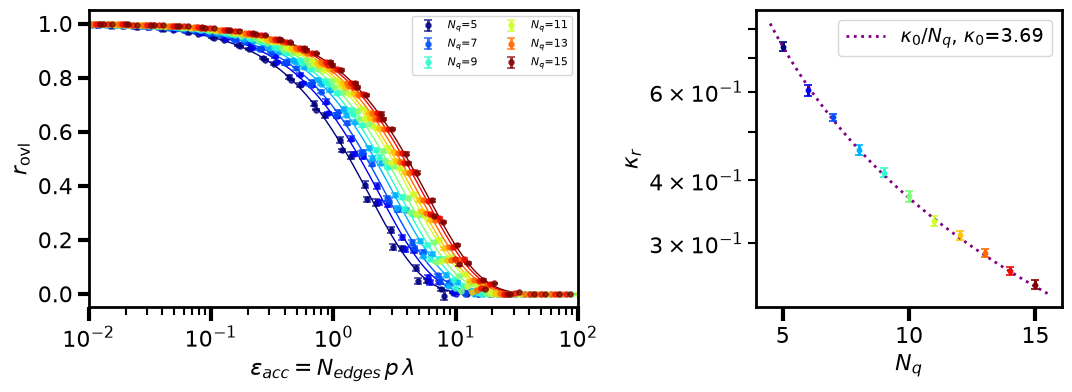

kappa_0 = 3.689 ± 0.012   (kappa_r = kappa_0 / N_q)


In [9]:
import json

from qecbench.noise_study import (accumulated_error, collapse, device_overlaps, device_run, fit_kappa,
                                  fit_kappa0, fit_lambda_eff, load_study, overlap_model)

STUDY = load_study(ROOT / "data" / "noise_study" / "chain_depolarizing.json")
NQS, STUDY_DEPTHS, LAMBDAS = list(range(5, 16)), [2, 5, 10], np.logspace(-5, 0, 25)
study = {key: d for key, d in STUDY.items() if key[1] in STUDY_DEPTHS}

fits_r = {n: fit_kappa(*collapse(study, n, LAMBDAS, "r")[:2]) for n in NQS}
KAPPA_0, kappa0_err, _ = fit_kappa0(NQS, [fits_r[n]["kappa"] for n in NQS])

cmap = plt.get_cmap("jet")
size_colour = {n: cmap(i / max(len(NQS) - 1, 1)) for i, n in enumerate(NQS)}
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
x = np.logspace(-2, 2, 300)
for n in NQS:
    eps, ovl, err, depth, tail = collapse(study, n, LAMBDAS, "r")
    keep = (eps >= 1e-2) & (eps <= 1e2)
    ax.errorbar(eps[keep], ovl[keep], yerr=err[keep], fmt="o", ms=3.5, color=size_colour[n], alpha=0.75,
                label=f"$N_q$={n}" if n % 2 else None)
    ax.plot(x, overlap_model(x, fits_r[n]["kappa"]), color=size_colour[n], lw=1)
ax.set(xscale="log", xlim=(1e-2, 1e2), ylim=(-0.05, 1.05), xlabel=r"$\varepsilon_{acc} = N_{edges}\,p\,\lambda$",
       ylabel=r"$r_{\rm ovl}$")
ax.legend(fontsize=8, ncol=2)
dense = np.linspace(min(NQS) - 0.5, max(NQS) + 0.5, 200)
for n in NQS:
    bx.errorbar(n, fits_r[n]["kappa"], yerr=3 * fits_r[n]["stderr"], fmt="o", color=size_colour[n], capsize=3)
bx.plot(dense, KAPPA_0 / dense, ":", color="purple", lw=2, label=fr"$\kappa_0/N_q$, $\kappa_0$={KAPPA_0:.2f}")
bx.set(yscale="log", xlabel="$N_q$", ylabel=r"$\kappa_r$")
bx.legend()
fig.tight_layout()
fig.savefig(FIGURES / "fig5a_kappa_r_scaling.pdf", transparent=True, bbox_inches="tight")
plt.show()
print(f"kappa_0 = {KAPPA_0:.3f} ± {kappa0_err:.3f}   (kappa_r = kappa_0 / N_q)")

### Fig. 5b - $\lambda_{\rm eff}$ of a 10-spin chain on IBM Boston and Helios-1E

Grey: the depolarizing simulation at $N_q = 10$ over the depths the devices ran ($p = 10\ldots50$), and its
fit. Coloured: device overlaps, each placed at $\varepsilon_{\rm acc} = 9\,p\,\lambda_{\rm eff}$ with its fitted
$\lambda_{\rm eff}$; circles are the direct circuit, triangles MCM. Left, the approximation ratio with
$\kappa_r = \kappa_0/10$; right, the probability of the optimum with $\kappa_\rho$ fitted at these depths.
Points that follow the grey curve degrade like uniform depolarizing noise.

**Data.** `data/results/ibm_boston/chain/{direct,mcm}/`: `20260506_1507` (direct) and `20260506_1537` (MCM),
10 000 shots, $p = 10\ldots50$. `data/results/Helios-1E/chain/{direct,mcm}/`: `20260507_0900` (direct) and
`20260508_0700` (MCM), 1 000 shots on **Quantinuum's Helios-1E emulator** (flagged as simulated),
$p = 1\ldots10, 15, 20, 30, 40, 50$. Overlaps above 1.2 (shot noise on nearly noiseless points) are set to 1.

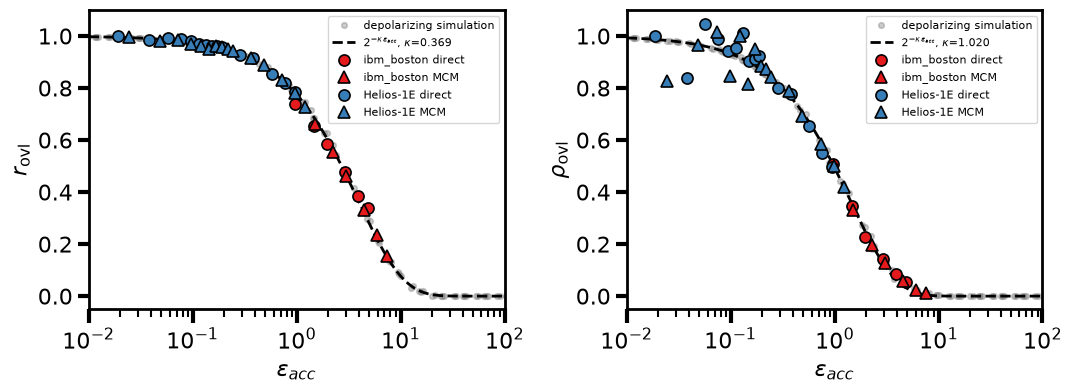

kappa_r = 0.369, kappa_rho = 1.020 (p = [10, 20, 30, 40, 50])

                       lambda_eff from r    from rho
ibm_boston direct               1.08e-02    1.08e-02
ibm_boston MCM                  1.66e-02    1.68e-02
Helios-1E direct                2.12e-03    2.09e-03
Helios-1E MCM                   2.68e-03    2.71e-03


In [10]:
DEVICE_N, DEEP_DEPTHS = 10, [10, 20, 30, 40, 50]
FIG5B_RUNS = {   # label -> (backend, kind, run stamps, depths)
    ("ibm_boston", "direct"): ("ibm_boston", "direct", ["20260506_1507"], [10, 15, 20, 30, 40, 50]),
    ("ibm_boston", "MCM"):    ("ibm_boston", "mcm", ["20260506_1537"], [10, 15, 20, 30, 40, 50]),
    ("Helios-1E", "direct"):  ("Helios-1E", "direct", ["20260507_0900"], [*range(1, 11), 15, 20, 30, 40, 50]),
    ("Helios-1E", "MCM"):     ("Helios-1E", "mcm", ["20260508_0700"], [*range(1, 11), 15, 20, 30, 40, 50]),
}
deep = {key: d for key, d in STUDY.items() if key[0] == DEVICE_N and key[1] in DEEP_DEPTHS}
kappa_rho = fit_kappa(*collapse(deep, DEVICE_N, LAMBDAS, "prob")[:2])["kappa"]
kappas = {"r": KAPPA_0 / DEVICE_N, "prob": kappa_rho}
set1 = plt.get_cmap("Set1")
device_colour, marker = {"ibm_boston": set1(0), "Helios-1E": set1(1)}, {"direct": "o", "MCM": "^"}

lambda_5b = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, observable, ylabel in zip(axes, ("r", "prob"), (r"$r_{\rm ovl}$", r"$\rho_{\rm ovl}$")):
    eps, ovl, *_ = collapse(deep, DEVICE_N, LAMBDAS, observable)
    ax.plot(eps, ovl, "o", color="gray", alpha=0.4, ms=4, label="depolarizing simulation")
    ax.plot(x, overlap_model(x, kappas[observable]), "--", color="black", lw=2,
            label=fr"$2^{{-\kappa\,\varepsilon_{{acc}}}}$, $\kappa$={kappas[observable]:.3f}")
    for (device, circuit), (backend, kind, stamps, depths) in FIG5B_RUNS.items():
        ps, values = device_overlaps(device_run(RESULTS, backend, kind, stamps, DEVICE_N, depths), DEVICE_N,
                                     observable=observable)
        fit = fit_lambda_eff(ps, values, DEVICE_N - 1, kappas[observable])
        lambda_5b[(device, circuit, observable)] = fit["lambda_eff"]
        ax.plot(accumulated_error(DEVICE_N - 1, ps, fit["lambda_eff"]), values, marker[circuit], ms=8,
                color=device_colour[device], mec="black", label=f"{device} {circuit}")
    ax.set(xscale="log", xlim=(1e-2, 1e2), ylim=(-0.05, 1.1), xlabel=r"$\varepsilon_{acc}$", ylabel=ylabel)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "fig5b_lambda_eff_nq10.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"kappa_r = {kappas['r']:.3f}, kappa_rho = {kappa_rho:.3f} (p = {DEEP_DEPTHS})\n")
print(f"{'':<20}{'lambda_eff from r':>20}{'from rho':>12}")
for device, circuit in FIG5B_RUNS:
    print(f"{device + ' ' + circuit:<20}{lambda_5b[(device, circuit, 'r')]:>20.2e}{lambda_5b[(device, circuit, 'prob')]:>12.2e}")

### Fig. 5c - $\lambda_{\rm eff}$ against chain length, across devices

The per-edge $\lambda_{\rm eff}$ of every device at every chain length it ran, for the direct circuit (circles,
solid lines) and the MCM circuit (crosses, dashed lines), with $\kappa_r = \kappa_0/N_q$ from Fig. 5a. The
chains run to $N_q = 60$, far past the $N_q \le 15$ of the simulation, so the $1/N_q$ law is extrapolated.
Dotted segments are Quantinuum **hardware**, a dotted link joins an emulator point to a hardware point, and the
Helios-1E emulator is left out so that no simulated point looks measured.

| device | direct circuits | MCM circuits |
|---|---|---|
| `ibm_boston`, `ibm_pittsburgh`, `ibm_kingston` | April-May 2026, $N_q = 10\ldots60$ | late August 2026, $N_q = 10\ldots60$ |
| Quantinuum Helios | Helios-1 hardware, $N_q = 30, 40, 50$ | Helios-1 hardware: $N_q = 20$ (15 September), $30, 40, 50$ (9 September) |
| Quantinuum H2 | H2-1E emulator $N_q = 10, 20$; H2-1 hardware $N_q = 30$ | same split, 20 August 2026 |
| `ibm_fez`, `ibm_marrakesh`, `ibm_phoenix` | - | late August / early September 2026 |

**Read the MCM curves against each other.** Every MCM curve here uses the two-colour ordering of the gadgets:
the IBM campaigns, the Helios-1 runs (the parallel program, Fig. 4) and the H2 runs. H2 does not run Guppy, so its
runs were built as pytket circuits in the earlier H2 campaign. That builder
colours the bonds into even and odd classes and gives each class a pool of $\lfloor N_q/2 \rfloor$ ancillas, reset and
reused between classes, since H2-1 has a fixed 56-qubit register. Within a class the gadgets touch disjoint data
qubits and disjoint ancillas, so none waits on another. The stored runs carry exactly those pools (5, 10 and 15
ancillas at $N_q = 10, 20, 30$), which confirms the colouring was used. The direct campaigns come from an earlier
period, and no direct runs were made alongside the new MCM ones.

**Fit windows.** MCM: $p = 3, 5, 10$, the only depths every device ran (Helios-1 stops at $p = 10$). This window
inflates $\lambda_{\rm eff}$ by roughly 1.2-1.5x against a $p \ge 10$ window, alike for every device. Direct:
every depth run among $3\ldots50$, after dropping the leading plateau (points up to the maximum overlap). Points
at or below random are dropped. There are no error bars: with 2-8 points per fit the curve-fit covariance
reflects how many points survived, not the measurement.

| device | circuit | runs in `data/results/<backend>/chain/<kind>/` |
|---|---|---|
| `ibm_boston` | direct | `20260512_1429` (10), `20260428_110845` (20), `_110857` (30), `_110905` (40), `_110915` (50), `20260430_0834` (60) |
| | MCM | `20260827_1035` |
| `ibm_pittsburgh` | direct | `20260512_1402` (10), `20260428_111001` (20), `_110953` (30), `_110944` (40), `_110932` (50), `20260430_1618` (60) |
| | MCM | `20260828_1025` |
| `ibm_kingston` | direct | `20260512_1402` (10), `20260505_0806` (20), `20260505_0805` (30-60) |
| | MCM | `20260827_1205` |
| Helios-1 | direct | `20260525_0957` (30), `20260309_0726` (40), `20260526_0802` (50) |
| | MCM | `20260915_1035` (20), `20260909_1423` (30), `_1509` (40), `_1521` (50) |
| H2-1E / H2-1 | direct | `20260820_0646` (H2-1E, 10, 20), `20260820_0651` (H2-1, 30) |
| | MCM | `20260820_0647` (H2-1E, 10, 20), `20260820_0650` (H2-1, 30) |
| `ibm_fez`, `ibm_marrakesh`, `ibm_phoenix` | MCM | `20260828_1028`, `20260828_1034`, `20260904_1435` |

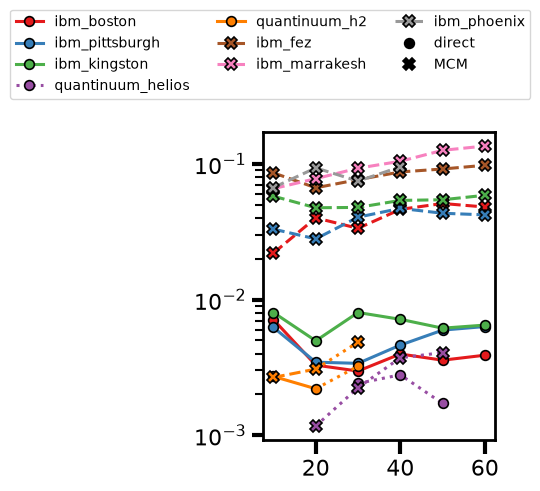

lambda_eff per edge, direct, window p = [3, 5, 10, 15, 20, 30, 40, 50] (leading plateau dropped)
                            10        20        30        40        50        60
ibm_boston            7.12e-03  3.29e-03  2.97e-03  3.97e-03  3.57e-03  3.89e-03
ibm_pittsburgh        6.23e-03  3.46e-03  3.39e-03  4.62e-03  5.95e-03  6.33e-03
ibm_kingston          8.03e-03  4.96e-03  8.03e-03  7.15e-03  6.16e-03  6.49e-03
quantinuum_helios            -         -  2.41e-03  2.79e-03  1.72e-03         -
quantinuum_h2         2.71e-03  2.20e-03  3.23e-03         -         -         -

lambda_eff per edge, mcm, window p = [3, 5, 10]
                            10        20        30        40        50        60
ibm_boston            2.21e-02  4.01e-02  3.36e-02  4.63e-02  5.12e-02  4.82e-02
ibm_pittsburgh        3.31e-02  2.80e-02  4.06e-02  4.71e-02  4.34e-02  4.22e-02
ibm_kingston          5.79e-02  4.76e-02  4.79e-02  5.39e-02  5.45e-02  5.88e-02
quantinuum_helios            -  1.17e-03  2.

In [11]:
from qecbench.noise_study import decaying_part

LAMBDA_SERIES = {   # device -> {circuit: [(backend, run stamp), ...]}
    "ibm_boston":        {"direct": [("ibm_boston", s) for s in ("20260512_1429", "20260428_110845", "20260428_110857",
                                                                  "20260428_110905", "20260428_110915", "20260430_0834")],
                          "mcm":    [("ibm_boston", "20260827_1035")]},
    "ibm_pittsburgh":    {"direct": [("ibm_pittsburgh", s) for s in ("20260512_1402", "20260428_111001", "20260428_110953",
                                                                      "20260428_110944", "20260428_110932", "20260430_1618")],
                          "mcm":    [("ibm_pittsburgh", "20260828_1025")]},
    "ibm_kingston":      {"direct": [("ibm_kingston", s) for s in ("20260512_1402", "20260505_0806", "20260505_0805")],
                          "mcm":    [("ibm_kingston", "20260827_1205")]},
    "quantinuum_helios": {"direct": [("Helios-1", s) for s in ("20260525_0957", "20260309_0726", "20260526_0802")],
                          "mcm":    [("Helios-1", s) for s in ("20260915_1035", "20260909_1423", "20260909_1509", "20260909_1521")]},
    "quantinuum_h2":     {"direct": [("H2-1E", "20260820_0646"), ("H2-1", "20260820_0651")],
                          "mcm":    [("H2-1E", "20260820_0647"), ("H2-1", "20260820_0650")]},
    "ibm_fez":           {"mcm": [("ibm_fez", "20260828_1028")]},
    "ibm_marrakesh":     {"mcm": [("ibm_marrakesh", "20260828_1034")]},
    "ibm_phoenix":       {"mcm": [("ibm_phoenix", "20260904_1435")]},
}
LAMBDA_COLOURS = {"ibm_boston": 0, "ibm_pittsburgh": 1, "ibm_kingston": 2, "quantinuum_helios": 3,
                  "quantinuum_h2": 4, "ibm_fez": 6, "ibm_marrakesh": 7, "ibm_phoenix": 8}   # Set1 indices
QUANTINUUM_HARDWARE = {"Helios-1", "H2-1"}                                                  # drawn dotted
LAMBDA_WINDOWS = {"direct": [3, 5, 10, 15, 20, 30, 40, 50], "mcm": [3, 5, 10]}
DROP_PLATEAU = {"direct": True, "mcm": False}


def lambda_vs_nq(backend, stamps, window, kind="mcm", drop_plateau=False):
    # {N_q: fit} with the per-edge model, kappa = kappa_0 / N_q, over the depths in `window`
    out = {}
    for chain, by_depth in runs(backend, stamps, kind=kind).items():
        n = chain.n_data
        ps = np.array([p for p in window if p in by_depth], dtype=float)
        ovl = np.array([by_depth[int(p)]["r_ovl"] for p in ps])
        ps, ovl = ps[ovl > 0], ovl[ovl > 0]
        if drop_plateau:
            ps, ovl = decaying_part(ps, ovl)
        if len(ps) >= 2:
            out[n] = {**fit_lambda_eff(ps, ovl, n - 1, KAPPA_0 / n), "backend": backend}
    return dict(sorted(out.items()))


lambda_by_nq = {}
for device, kinds in LAMBDA_SERIES.items():
    for kind, device_runs in kinds.items():
        stamps_by_backend = {}
        for backend, stamp in device_runs:
            stamps_by_backend.setdefault(backend, []).append(stamp)
        lambda_by_nq[(device, kind)] = {}
        for backend, stamps in stamps_by_backend.items():
            lambda_by_nq[(device, kind)].update(lambda_vs_nq(backend, stamps, LAMBDA_WINDOWS[kind], kind, DROP_PLATEAU[kind]))

colours = plt.get_cmap("Set1")
style = {"direct": dict(marker="o", ls="-", ms=7), "mcm": dict(marker="X", ls="--", ms=8)}
fig, ax = plt.subplots(figsize=(3, 4))
for device, kinds in LAMBDA_SERIES.items():
    colour = colours(LAMBDA_COLOURS[device])
    labelled = False
    for kind in kinds:
        fits = lambda_by_nq[(device, kind)]
        segments = []                               # consecutive points on the same backend
        for n in sorted(fits):
            if segments and segments[-1][0] == fits[n]["backend"]:
                segments[-1][1].append(n)
            else:
                segments.append((fits[n]["backend"], [n]))
        previous = None
        for backend, nqs in segments:
            ys = [fits[n]["lambda_eff"] for n in nqs]
            ax.plot(nqs, ys, color=colour, mec="black", marker=style[kind]["marker"], ms=style[kind]["ms"],
                    ls=":" if backend in QUANTINUUM_HARDWARE else style[kind]["ls"], label=None if labelled else device)
            labelled = True
            if previous is not None:
                ax.plot([previous[0], nqs[0]], [previous[1], ys[0]], color=colour, ls=":")
            previous = (nqs[-1], ys[-1])
ax.plot([], [], "o", color="black", ms=7, markeredgecolor="black", linestyle="None", label="direct")
ax.plot([], [], "X", color="black", ms=8, markeredgecolor="black", linestyle="None", label="MCM")
ax.set_yscale("log")
if SHOW_LABELS:
    ax.set(xlabel="$N_q$", ylabel=r"$\lambda_{\rm eff}$ per edge")
ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(1.18, 1.42), ncols=3)
fig.savefig(FIGURES / "fig5c_lambda_eff_by_nq.pdf", transparent=True, bbox_inches="tight")
plt.show()

sizes = sorted({n for fits in lambda_by_nq.values() for n in fits})
for kind in ("direct", "mcm"):
    print(f"lambda_eff per edge, {kind}, window p = {LAMBDA_WINDOWS[kind]}"
          + (" (leading plateau dropped)" if DROP_PLATEAU[kind] else ""))
    print(f"{'':<20}" + "".join(f"{n:>10}" for n in sizes))
    for device in LAMBDA_SERIES:
        fits = lambda_by_nq.get((device, kind))
        if fits:
            print(f"{device:<20}" + "".join(f"{fits[n]['lambda_eff']:>10.2e}" if n in fits else f"{'-':>10}" for n in sizes))
    print()

### Fig. 5d - MCM error per edge against when each device became available

For eight devices, the mean MCM $\lambda_{\rm eff}$ over the chain lengths measured (bars: min-max over $N_q$,
the spread across chain length, not a shot-noise error), placed at the device's first public availability.
Shaded bands cover each vendor's range, and the dashed lines are a guide to the eye: a least-squares line
through $\log_{10}\lambda$ against release date, i.e. a constant factor per year. The two vendors are kept as
separate families. Every IBM superconducting device sits about an order of magnitude above Quantinuum's
trapped-ion machines, so one trend through all points would hide the main result. With 6 IBM points over 4
processor families and 2 Quantinuum points, the trends are anecdotes, not measurements.

**Fits.** $p = 3, 5, 10$ for every device (the only depths every device ran; Helios-1 stops at $p = 10$). The
exception is `ibm_phoenix`, which has no $p = 3$ and reaches the random floor by $p \approx 25$, so it uses
$p = 5, 10, 15, 20$. Two caveats flatter Phoenix: only $N_q = 10\ldots40$ could be embedded cleanly (its
$\lambda_{\rm eff}$ grows with $N_q$), and dropping $p = 3$ alone lowers $\lambda$ by about 1.3x.

**Release dates** are metadata, not data: first public availability as announced by the vendor (`precision`
says whether the date is the system's or only its processor family's, and the source of each is listed).

| device | MCM run(s) in `data/results/<device>/chain/mcm/` | $N_q$ |
|---|---|---|
| `ibm_fez` | `20260828_1028` | 10-60 |
| `ibm_marrakesh` | `20260828_1034` | 10-60 |
| `ibm_kingston` | `20260827_1205` | 10-60 |
| `ibm_pittsburgh` | `20260828_1025` | 10-60 |
| `ibm_boston` | `20260827_1035` | 10-60 |
| `ibm_phoenix` | `20260904_1435` | 10-40 |
| `H2-1` | `20260820_0650` | 30 |
| `Helios-1` | `20260909_1423`, `_1509`, `_1521` | 30-50 |

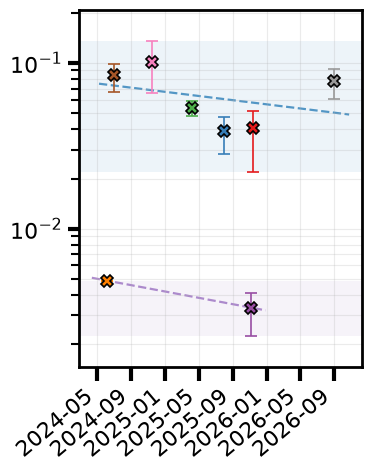

geometric mean lambda_eff (MCM): IBM 6.177e-02, Quantinuum 4.028e-03 -> IBM is 15.3x higher
   IBM         x0.84 per year, R2 = 0.11, n = 6
   Quantinuum  x0.77 per year, R2 = 1.00, n = 2   <- 2 points, the slope is not a measurement

device          first available  processor             precision  window           mean lambda               min - max  N_q
H2-1            2024-06-05       Quantinuum H2 (56q)   system     [3, 5, 10]         4.856e-03   4.856e-03 - 4.856e-03    1
ibm_fez         2024-07-01       Heron r2              month      [3, 5, 10]         8.447e-02   6.681e-02 - 9.792e-02    6
ibm_marrakesh   2024-11-13       Heron r2              system     [3, 5, 10]         1.006e-01   6.585e-02 - 1.358e-01    6
ibm_kingston    2025-04-09       Heron r2              system     [3, 5, 10]         5.344e-02   4.759e-02 - 5.880e-02    6
ibm_pittsburgh  2025-07-31       Heron r3              system     [3, 5, 10]         3.905e-02   2.805e-02 - 4.708e-02    6
Helios-1        2025-

In [12]:
import datetime

import matplotlib.dates as mdates

WINDOW_5D = [3, 5, 10]
DEVICE_INTRO = {   # device -> run stamps, Set1 colour, first availability, processor, precision, source
    "ibm_fez": dict(stamps=["20260828_1028"], c=6, date="2024-07-01", processor="Heron r2", precision="month",
                    source="https://qpustatus.com/ibm-fez"),
    "ibm_marrakesh": dict(stamps=["20260828_1034"], c=7, date="2024-11-13", processor="Heron r2", precision="system",
                          source="https://qpustatus.com/ibm-marrakesh"),
    "ibm_kingston": dict(stamps=["20260827_1205"], c=2, date="2025-04-09", processor="Heron r2", precision="system",
                         source="https://quantum.cloud.ibm.com/announcements/product-updates/2025-04-09-aachen-kingston"),
    "ibm_pittsburgh": dict(stamps=["20260828_1025"], c=1, date="2025-07-31", processor="Heron r3", precision="system",
                           source="https://quantum.cloud.ibm.com/announcements/en/product-updates/2025-07-31-pittsburgh-sherbrooke"),
    "ibm_boston": dict(stamps=["20260827_1035"], c=0, date="2025-11-12", processor="Heron r3", precision="system",
                       note="access expanded 2026-01", source="https://research.ibm.com/events/qdc-2025"),
    "H2-1": dict(stamps=["20260820_0650"], c=4, date="2024-06-05", processor="Quantinuum H2 (56q)", precision="system",
                 source="https://www.quantinuum.com/press-releases/quantinuum-launches-industry-first-trapped-ion-56-qubit-quantum-computer-that-challenges-the-worlds-best-supercomputers"),
    "ibm_phoenix": dict(stamps=["20260904_1435"], c=8, date="2026-09-02", processor="Nighthawk r2", precision="system",
                        window=[5, 10, 15, 20],
                        source="https://quantumcomputingreport.com/ibm-releases-nighthawk-r2-qpu-featuring-active-dissipative-qubit-reset-and-25x-circuit-throughput/"),
    "Helios-1": dict(stamps=["20260909_1423", "20260909_1509", "20260909_1521"], c=3, date="2025-11-05",
                     processor="Quantinuum Helios", precision="system",
                     source="https://thequantuminsider.com/2025/11/05/quantinuum-announces-commercial-launch-of-helios-a-quantum-computer-with-accuracy-to-enable-generative-quantum-ai/"),
}
VENDORS = {"IBM": ("IBM (superconducting)", "tab:blue"), "Quantinuum": ("Quantinuum (trapped ion)", "tab:purple")}

rows = []
for device, info in DEVICE_INTRO.items():
    window = info.get("window", WINDOW_5D)
    values = np.array([f["lambda_eff"] for f in lambda_vs_nq(device, info["stamps"], window).values()])
    rows.append(dict(dev=device, vendor="IBM" if device.startswith("ibm_") else "Quantinuum",
                     date=datetime.date.fromisoformat(info["date"]), mean=float(values.mean()),
                     lo=float(values.min()), hi=float(values.max()), n=len(values), window=window,
                     **{k: v for k, v in info.items() if k not in ("date", "window")}))
rows.sort(key=lambda r: r["date"])

fig, ax = plt.subplots(figsize=(4, 5))
trend = {}
for vendor, (label, colour) in VENDORS.items():
    group = [r for r in rows if r["vendor"] == vendor]
    ax.axhspan(min(r["lo"] for r in group), max(r["hi"] for r in group), color=colour, alpha=0.08, lw=0, zorder=0)
    years = np.array([r["date"].toordinal() / 365.25 for r in group])
    log_lambda = np.log10([r["mean"] for r in group])
    slope, intercept = np.polyfit(years, log_lambda, 1)
    residual = log_lambda - (slope * years + intercept)
    total = float(((log_lambda - log_lambda.mean()) ** 2).sum())
    trend[vendor] = dict(per_year=10 ** slope, r2=1 - float((residual ** 2).sum()) / total if total > 0 else np.nan,
                         n=len(group))
    span = np.linspace(years.min() - 0.15, years.max() + 0.15, 50)
    ax.plot([datetime.date.fromordinal(int(v * 365.25)) for v in span], 10 ** (slope * span + intercept),
            "--", color=colour, lw=1.6, alpha=0.75, zorder=1)
set1 = plt.get_cmap("Set1")
for r in rows:
    ax.errorbar(r["date"], r["mean"], yerr=[[r["mean"] - r["lo"]], [r["hi"] - r["mean"]]], marker="X",
                color=set1(r["c"]), markersize=9, markeredgecolor="black", capsize=4, elinewidth=1.2, capthick=1.2)
ax.set_yscale("log")
low, high = ax.get_ylim()
ax.set_ylim(low / 1.25, high * 1.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(rotation=40)
ax.grid(alpha=0.25, which="both")
if SHOW_LABELS:
    ax.set(xlabel="first available", ylabel=r"mean $\lambda_{eff}$ per edge (MCM)")
plt.tight_layout()
fig.savefig(FIGURES / "fig5d_mcm_error_vs_device_intro.pdf", transparent=True, bbox_inches="tight")
plt.show()

geo = {v: float(np.exp(np.mean(np.log([r["mean"] for r in rows if r["vendor"] == v])))) for v in VENDORS}
print(f"geometric mean lambda_eff (MCM): IBM {geo['IBM']:.3e}, Quantinuum {geo['Quantinuum']:.3e} "
      f"-> IBM is {geo['IBM'] / geo['Quantinuum']:.1f}x higher")
for vendor, t in trend.items():
    print(f"   {vendor:<11} x{t['per_year']:.2f} per year, R2 = {t['r2']:.2f}, n = {t['n']}"
          + ("   <- 2 points, the slope is not a measurement" if t["n"] <= 2 else ""))
print(f"\n{'device':<16}{'first available':<17}{'processor':<22}{'precision':<11}{'window':<16}{'mean lambda':>12}"
      f"{'min - max':>24}{'N_q':>5}")
for r in rows:
    print(f"{r['dev']:<16}{str(r['date']):<17}{r['processor']:<22}{r['precision']:<11}{str(r['window']):<16}"
          f"{r['mean']:>12.3e}{r['lo']:>12.3e} - {r['hi']:.3e}{r['n']:>5}")
print("\nsources:")
for r in rows:
    print(f"  {r['dev']:<16}{r['source']}")

## 7. Fig. 6 - QEC structures across QPUs: how far the signal survives with size

LR-QAOA on the check Hamiltonian of a code, $H = \sum_c \prod_{i \in S_c} Z_i$, where each MCM term is one
syndrome-extraction gadget, so one layer is one round of syndrome extraction
(`benchmark_codes_quantinuum.ipynb`, section 0). One figure for every structure that was run: the approximation
ratio $r$ each code reaches at its **best depth**, against the number of data qubits.

* **colour** is the machine (Helios-1 red, H2-1 blue, IBM Phoenix green); an **emulator** shares its machine's
  colour but is drawn hollow, so a noise model is never mistaken for a measurement;
* **marker** is the code family: circle for the surface code, square for the colour code, triangle for qLDPC;
* the **faint points** are the other depths measured at the same size, so the vertical spread behind each
  highlighted point is its depth dependence, and the label gives the depth at which the best $r$ was measured.
  Where a size was run more than once, the newest run wins at each depth, so a faint point can come from an
  earlier state of the machine;
* **error bars** are one standard deviation of shot noise (10-50 shots on the trapped-ion runs, 500-1000 on
  Phoenix, so they differ a lot between points);
* the grey line at $r = 0.5$ is the random-sampling limit, identical for every code here.

This is $r$ and not $r_{\rm ovl}$: a noiseless reference exists only for the small structures (surface $d = 3, 5$,
colour $d = 3, 5$, BB18, BB30), so normalising would drop every large Helios-1 point, which is where the
question - how far does the structure survive? - is actually decided.

**Coverage is what the hardware ran, not a choice.** Phoenix has the surface code only, H2-1 the surface code at
$d = 5$ and the colour code at $d = 7$, and the qLDPC family exists on Helios-1 alone. The direct (CNOT-ladder) implementation was run for most of
these structures and stays in `data/results/<backend>/<family>/direct/`; it is left out here because the object
is the code's own measurement pattern, not the ancilla-free circuit, which no syndrome extraction would use.

**Runs.** Converted from earlier result files by `scripts/import_legacy_codes.py` into
`data/results/<backend>/<family>/<kind>/`; the run files are named in the cell.

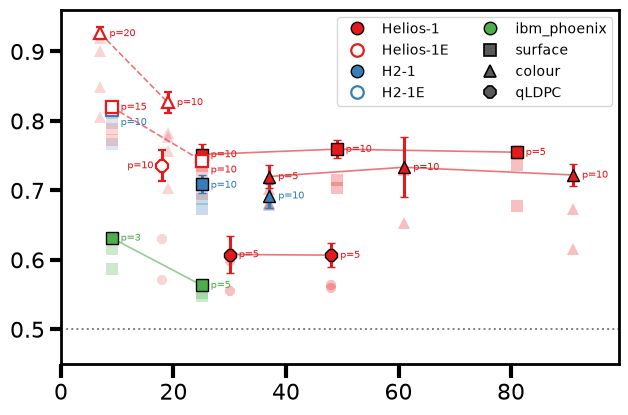

       code       device  N_q    best r      +-    p  shots   every depth (MCM)
   color_d3    Helios-1E    7     0.926   0.009   20    500   p3:0.805  p5:0.849  p10:0.900  p15:0.920  p20:0.926
   color_d5    Helios-1E   19     0.827   0.015   10    100   p3:0.703  p5:0.757  p10:0.827  p15:0.782  p20:0.777
   color_d7         H2-1   37     0.692   0.017   10     50   p3:0.679  p5:0.682  p10:0.692
   color_d7     Helios-1   37     0.720   0.016    5     50   p3:0.681  p5:0.720  p10:0.702
   color_d9     Helios-1   61     0.733   0.043   10     10   p3:0.653  p5:0.730  p10:0.733
  color_d11     Helios-1   91     0.722   0.016   10     10   p3:0.616  p5:0.673  p10:0.722
       BB18    Helios-1E   18     0.736   0.022   10    100   p3:0.571  p5:0.631  p10:0.736
       BB30     Helios-1   30     0.608   0.026    5     20   p3:0.556  p5:0.608  p10:0.598
       BB48     Helios-1   48     0.607   0.017    5     20   p3:0.559  p5:0.607  p10:0.563
 surface_d3        H2-1E    9     0.816   0.006 

In [13]:
import warnings

from matplotlib.lines import Line2D

from qecbench import codes

FIG6_RUNS = {   # device: {family: run stamps}
    "Helios-1": {"color_code": ["20260316_1424", "20260825_1231", "20260924_101609"],
                 "surface_code": ["20260309_1631", "20260825_1229", "20260918_100200", "20260922_091417"],
                 "qldpc": ["20260702_0853"]},
    "Helios-1E": {"color_code": ["20260316_1139"], "qldpc": ["20260629_0732"],
                  "surface_code": ["20260306_1514", "20260306_1518", "20260309_1203", "20260310_1119"]},
    "H2-1": {"color_code": ["20260820_1140"], "surface_code": ["20260820_0736"]},
    "H2-1E": {"surface_code": ["20260820_0707"]},
    "ibm_phoenix": {"surface_code": ["20260909_1619", "20260909_1631"]},
}
FIG6_DEVICES = {"Helios-1": ("Helios-1", "#e41a1c", False), "Helios-1E": ("Helios-1E", "#e41a1c", True),
                "H2-1": ("H2-1", "#377eb8", False), "H2-1E": ("H2-1E", "#377eb8", True),
                "ibm_phoenix": ("ibm_phoenix", "#4daf4a", False)}
FIG6_FAMILIES = {"surface_code": ("surface", "s"), "color_code": ("colour", "^"), "qldpc": ("qLDPC", "8")}

best, every = {}, {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")        # r_ideal is NaN above 25 data qubits; this figure uses r
    for device, families in FIG6_RUNS.items():
        for family, stamps in families.items():
            for patch, by_depth in runs(device, stamps, "mcm", family).items():
                key = (device, family, patch.n_data)
                every[key] = {p: s for p, s in sorted(by_depth.items())}
                top = max(by_depth, key=lambda p: by_depth[p]["r"])
                best[key] = {**by_depth[top], "depth": top, "code": patch.code.name}

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.axhline(0.5, color="grey", ls=":", lw=1.4, zorder=0)
for (device, family, n_data), by_depth in sorted(every.items()):
    colour, emulator = FIG6_DEVICES[device][1], FIG6_DEVICES[device][2]
    others = [s["r"] for p, s in by_depth.items() if p != best[(device, family, n_data)]["depth"]]
    ax.plot([n_data] * len(others), others, FIG6_FAMILIES[family][1], ms=8, color=colour,
            alpha=0.18 if emulator else 0.28, mec="none", zorder=1)
for (device, family, n_data), v in sorted(best.items()):
    label, colour, emulator = FIG6_DEVICES[device]
    ax.errorbar(n_data, v["r"], yerr=v["r_err"], fmt=FIG6_FAMILIES[family][1], ms=9, color=colour, capsize=3,
                markerfacecolor="white" if emulator else colour, markeredgewidth=1.6 if emulator else 1.0,
                markeredgecolor=colour if emulator else "black", zorder=3)
LABEL_GAP, LABEL_REACH = 0.022, 8      # one line of the p labels, in r; how far a label runs, in N_q
for n_data in sorted({n for *_, n in best}):
    # the labels of one size, top to bottom, each at least a line below the one above it
    y = np.inf
    for r, device, family in sorted(((v["r"], dev, fam) for (dev, fam, n), v in best.items() if n == n_data),
                                    reverse=True):
        y = min(r, y - LABEL_GAP)
        # to the right, unless a point of a larger code sits in the label's way
        blocked = any(n_data < n <= n_data + LABEL_REACH and abs(v["r"] - y) < 1.5 * LABEL_GAP
                      for (_, _, n), v in best.items())
        ax.annotate(f"p={best[(device, family, n_data)]['depth']}", (n_data, r),
                    xytext=(n_data - 1.6 if blocked else n_data + 1.6, y), textcoords="data", va="center",
                    ha="right" if blocked else "left", fontsize=7.5, color=FIG6_DEVICES[device][1])
ax.set_xlim(0, 1.09 * max(n for *_, n in best))      # room for the labels of the widest code
for device, (label, colour, emulator) in FIG6_DEVICES.items():      # join each device-family series
    for family in FIG6_FAMILIES:
        pts = sorted((n, v["r"]) for (dev, fam, n), v in best.items() if dev == device and fam == family)
        if len(pts) > 1:
            ax.plot(*zip(*pts), "--" if emulator else "-", color=colour, lw=1.2, alpha=0.6, zorder=2)
ax.set_ylim(0.45, 0.96)
ax.legend(handles=[Line2D([], [], ls="", marker="o", color=c, ms=9, label=lab,
                          markerfacecolor="white" if emu else c, markeredgecolor=c if emu else "black",
                          markeredgewidth=1.6 if emu else 1.0) for lab, c, emu in FIG6_DEVICES.values()]
                 + [Line2D([], [], ls="", marker=mk, color="0.35", mec="black", ms=9, label=lab)
                    for lab, mk in FIG6_FAMILIES.values()],
          fontsize=10, loc="upper right", frameon=True, ncol=2)
if SHOW_LABELS:
    ax.set(xlabel="data qubits $N_q$", ylabel="$r$ at the best depth")
fig.savefig(FIGURES / "fig6_code_r_vs_nq_best_depth.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"{'code':>11} {'device':>12} {'N_q':>4} {'best r':>9} {'+-':>7} {'p':>4} {'shots':>6}   every depth (MCM)")
for (device, family, n_data), v in sorted(best.items(), key=lambda kv: (kv[0][1], kv[0][2], kv[0][0])):
    depths = "  ".join(f"p{p}:{s['r']:.3f}" for p, s in every[(device, family, n_data)].items())
    print(f"{v['code']:>11} {device:>12} {n_data:>4} {v['r']:>9.3f} {v['r_err']:>7.3f} {v['depth']:>4} "
          f"{v['shots']:>6}   {depths}")

## 8. Fig. 7 - the shot budget: separating LR-QAOA from random guessing

A result is the mean of $S$ single-shot values of $r$. Random guessing gives $r_{\rm rand} = 1/2$ with spread
$\sigma_{\rm rand}(S) = \sqrt{\sum_c w_c^2 / S}\,/\,(E_{\max} - E_{\min})$. How often does the mean of $S$ shots of a
*noiseless* device clear $r_{\rm rand} + 3\sigma_{\rm rand}(S)$? That is the least budget any device needs to tell its
result apart from random guessing (`qecbench.shots`). The dashed line marks 95 %.

* **Fig. 7a** - surface code $d = 3$ and $d = 5$ (9 and 25 data qubits) at $p = 3$.
* **Fig. 7b** - BB qLDPC codes BB18, BB24 and BB30 (18, 24 and 30 data qubits) at $p = 3$.

**Data and what differs from the published panels.** No device data. The random threshold is exact, and so is the
noiseless single-shot distribution up to 25 data qubits (`lrqaoa.ideal_energy_distribution`: one probability per
energy level; the 24- and 25-qubit ones are kept in `data/references/ideal_energies.json`). BB30 is past the exact
limit, so its distribution is the energy histogram of the published 10 000-shot noiseless simulation, stored in the
same file by `scripts/import_legacy_codes.py --references`. The published panels resampled 500-shot (surface code)
and 10 000-shot (qLDPC) simulations and a 200 000-bitstring random pool instead. That moves the probabilities by a
few hundredths at most and leaves the shots needed for 95 % unchanged or one grid step apart; the cells below print
both.

In [14]:
from qecbench import CodePatch
from qecbench.shots import ideal_r_distribution, separation_probability, shots_to_separate


def separation_panel(patches, shots_grid, published, figsize, xticks, name, label, legend_loc="best"):
    # P(mean of S noiseless shots > r_rand + 3 sigma_rand(S)) against S, one line per code
    fig, ax = plt.subplots(figsize=figsize)
    print(f"{'code':>11} {'data qubits':>12} {'noiseless r':>12}   S = {shots_grid}")
    for k, patch in enumerate(patches):
        values, probabilities = ideal_r_distribution(patch, depth=3)
        separated = separation_probability(patch, values, probabilities, shots_grid, n_sigma=3, n_boot=20_000,
                                           seed=260708)
        ax.plot(shots_grid, separated, "-o", color=plt.get_cmap("Set1")(k), label=label(patch), markersize=5)
        print(f"{patch.code.name:>11} {patch.n_data:>12} {values @ probabilities:>12.4f}   {np.round(separated, 3)}"
              f"   -> 95% at S = {shots_to_separate(shots_grid, separated)}")
        print(f"{'published':>11} {'':>12} {'':>12}   {np.array(published[patch.code.name])}"
              f"   -> 95% at S = {shots_to_separate(shots_grid, published[patch.code.name])}")
    ax.axhline(0.95, color="k", ls="--", lw=1.1, label="95%")
    ax.legend(fontsize=10, loc=legend_loc)
    ax.grid(True, which="both", ls=":", alpha=0.45)
    ax.set_xticks(xticks, xticks)
    if SHOW_LABELS:
        ax.set(xlabel="shots $S$", ylabel=r"$P(\bar r > r_{\rm rand} + 3\sigma_{\rm rand})$")
    fig.savefig(FIGURES / name, transparent=True, bbox_inches="tight")
    plt.show()

### Fig. 7a - surface code, $d = 3, 5$

       code  data qubits  noiseless r   S = [5, 10, 20, 30]
 surface_d3            9       0.7737   [0.747 0.983 1.    1.   ]   -> 95% at S = 10
  published                             [0.725 0.975 1.    1.   ]   -> 95% at S = 10
 surface_d5           25       0.7311   [0.984 1.    1.    1.   ]   -> 95% at S = 5
  published                             [0.979 1.    1.    1.   ]   -> 95% at S = 5


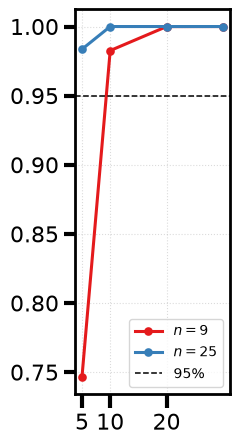

In [15]:
separation_panel([CodePatch(codes.surface_code(d)) for d in (3, 5)], shots_grid=[5, 10, 20, 30],
                 published={"surface_d3": [0.725, 0.975, 1, 1], "surface_d5": [0.979, 1, 1, 1]},
                 figsize=(2, 5), xticks=[5, 10, 20], name="fig7a_surface_code_shots_to_separate.pdf",
                 label=lambda patch: f"$n={patch.n_data}$", legend_loc="lower right")

### Fig. 7b - BB qLDPC codes, BB18, BB24, BB30

       code  data qubits  noiseless r   S = [5, 10, 20, 30, 50, 75, 100, 125, 150, 200]
       BB18           18       0.5736   [0.124 0.22  0.358 0.519 0.725 0.871 0.944 0.977 0.992 0.999]   -> 95% at S = 125
  published                             [0.119 0.211 0.352 0.477 0.728 0.868 0.934 0.978 0.988 0.998]   -> 95% at S = 125
       BB24           24       0.6051   [0.228 0.487 0.814 0.949 0.997 1.    1.    1.    1.    1.   ]   -> 95% at S = 50
  published                             [0.248 0.504 0.853 0.956 0.997 1.    1.    1.    1.    1.   ]   -> 95% at S = 30
       BB30           30       0.6164   [0.369 0.727 0.971 0.998 1.    1.    1.    1.    1.    1.   ]   -> 95% at S = 20
  published                             [0.372 0.727 0.96  0.998 1.    1.    1.    1.    1.    1.   ]   -> 95% at S = 20


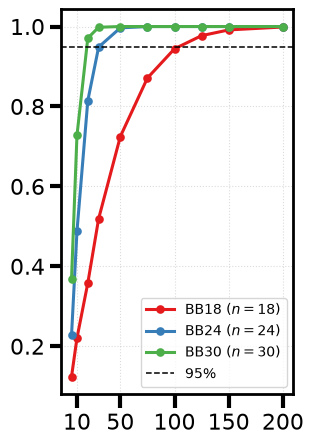

In [16]:
separation_panel([CodePatch(codes.bivariate_bicycle(name)) for name in ("BB18", "BB24", "BB30")],
                 shots_grid=[5, 10, 20, 30, 50, 75, 100, 125, 150, 200],
                 published={"BB18": [0.119, 0.211, 0.352, 0.477, 0.728, 0.868, 0.934, 0.978, 0.988, 0.998],
                            "BB24": [0.248, 0.504, 0.853, 0.956, 0.997, 1, 1, 1, 1, 1],
                            "BB30": [0.372, 0.727, 0.96, 0.998, 1, 1, 1, 1, 1, 1]},
                 figsize=(3, 5), xticks=[10, 50, 100, 150, 200], name="fig7b_qldpc_shots_to_separate.pdf",
                 label=lambda patch: f"{patch.code.name} ($n={patch.n_data}$)")

## 9. Fig. 8 - ranking devices: the shots it takes, and the surface code across machines

* **Fig. 8a** - how many shots per device LR-QAOA needs to rank two devices whose error rates differ by a factor of
  two, at $3\sigma$: $S^* = 9\,(\sigma_A^2 + \sigma_B^2)/(\mu_B - \mu_A)^2$, with $\mu$ and $\sigma$ the mean and spread of
  the single-shot $r$ (`shots.shots_to_rank`), against depth. Surface code $d = 3$ from noisy simulations (direct
  circuit, two-qubit depolarizing $\lambda$ after every CNOT, 50 000 shots per device and depth) and colour code
  $d = 5$ from a white-noise model, for $\lambda = 0.02/0.01$ and $0.002/0.001$. $S^*$ has a minimum in depth: too
  shallow and the two devices barely differ, too deep and both are near random.
* **Fig. 8b, 8c** - MCM approximation ratio $r$ of the surface code $d = 3$ (9 data qubits) and $d = 5$ (25) against
  depth on H2-1, Helios-1 and IBM Phoenix, with the H2-1E and Helios-1E emulators (dashed), the exact noiseless
  curve (black) and the random-guessing limit $r = 0.5$ (dotted). Plotting $r$ rather than $r_{\rm ovl}$ keeps the
  panel meaningful for codes too large to simulate: the device curve and the random limit need no reference, and the
  noiseless curve is drawn where one exists. Neither Quantinuum machine ran
  $d = 3$ on hardware, and H2-1E never ran $d = 5$. IBM Phoenix is the best patch of the position scan
  (`benchmark_codes_ibm.ipynb`): anchor $(r_0, c_0) = (7, 4)$ for $d = 3$ and $(2, 4)$ for $d = 5$; the trapped-ion
  machines are all-to-all and have no patch to choose, so this favours Phoenix.

**Data.**
* 8a: `data/shot_budget/two_device_ranking.json` (`scripts/import_shot_budget.py`). For the surface code it holds
  the means and spreads of the noisy simulations, which is all $S^*$ needs (the samples were not kept). For the
  colour code it holds the model constant $c = \kappa_0(n)\,N_{\rm CX} = 17.77$ ($N_{\rm CX} = 66$ per layer) and the
  depths; the model distribution $A\,P_{\rm ideal} + (1 - A)\,P_{\rm random}$, $A = 2^{-c p \lambda}$, is recomputed from
  the exact noiseless and random distributions and reproduces the published curve. Here $\lambda$ is that model's
  parameter, counted per CNOT, not the per-edge $\lambda$ of Fig. 4 and 5.
* 8b, 8c: converted by `scripts/import_legacy_codes.py`, for each device and depth the run with the most shots
  (the earliest when tied), as the published panels chose. The IBM files store logical labels; the conversion puts
  them back on the physical patch (`--anchor`), which `layout.surface_code_placements` reproduces qubit for qubit
  from the position scan's layout.

| panel | device | run files (`data/results/<device>/surface_code/mcm/`) | shots |
|---|---|---|---|
| 8b | H2-1E | `20260820_0707` | 500 |
| 8b | Helios-1E | `20260306_1514` ($p = 3, 5$), `20260306_1518` ($p = 10$) | 500 |
| 8b | ibm_phoenix | `20260909_1631` | 1000 |
| 8c | H2-1 | `20260820_0736` | 50 |
| 8c | Helios-1 | `20260825_1229` | 50 |
| 8c | Helios-1E | `20260309_1203` | 500 |
| 8c | ibm_phoenix | `20260909_1619` | 1000 |

**What differs from the published panels.** The values of $r$ are unchanged. The panels now show $r$ itself; the noiseless
curve is exact (e.g. $d = 3$, $p = 3$: 0.7737, where the published panels used a sampled simulation giving 0.7717).
The tables print the published $r_{\rm ovl}$ of each run underneath for comparison.

                       curve  S* (3 sigma) by depth
       surface d=3 0.02/0.01  p=3: 177, p=5: 97, p=8: 90, p=12: 136
     surface d=3 0.002/0.001  p=3: 4658, p=10: 280, p=25: 95, p=42: 67, p=60: 58, p=85: 64
colour d=5 (model) 0.02/0.01  p=1: 8396, p=3: 337, p=5: 151, p=7: 123, p=11: 147, p=15: 244
colour d=5 (model) 0.002/0.001  p=3: 10029, p=12: 333, p=28: 132, p=49: 94, p=73: 90, p=106: 114, p=146: 193


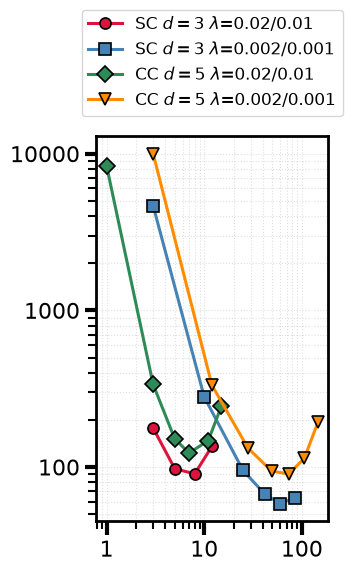

In [17]:
from qecbench.shots import (moments, random_r_distribution, shots_to_rank, white_noise_distribution)

budget = json.loads((ROOT / "data" / "shot_budget" / "two_device_ranking.json").read_text())

fig, ax = plt.subplots(figsize=(3, 5))
print(f"{'curve':>28}  S* (3 sigma) by depth")
for pair, colour, marker in (("0.02/0.01", "crimson", "o"), ("0.002/0.001", "steelblue", "s")):
    data = budget["surface_d3"]["pairs"][pair]["moments"]
    depths = sorted(int(p) for p in data)
    s_star = [shots_to_rank(data[str(p)]["mean_worse"], data[str(p)]["std_worse"],
                            data[str(p)]["mean_better"], data[str(p)]["std_better"], z=3) for p in depths]
    ax.plot(depths, s_star, marker + "-", color=colour, ms=8, mec="k", label=rf"SC $d=3$ $\lambda$={pair}")
    print(f"{'surface d=3 ' + pair:>28}  " + ", ".join(f"p={p}: {s:.0f}" for p, s in zip(depths, s_star)))

model = budget["color_d5_model"]
patch = CodePatch(codes.color_code(5), kind="direct")
rand_values, rand_probabilities = random_r_distribution(patch)
for pair, colour, marker in (("0.02/0.01", "seagreen", "D"), ("0.002/0.001", "darkorange", "v")):
    spec = model["pairs"][pair]
    s_star = []
    for p in spec["depths"]:
        values, ideal = ideal_r_distribution(patch, p)
        worse, better = (moments(values, white_noise_distribution(ideal, rand_probabilities, 2.0 ** (-model["c"] * p * lam)))
                         for lam in (spec["lambda_worse"], spec["lambda_better"]))
        s_star.append(shots_to_rank(*worse, *better, z=3))
    ax.plot(spec["depths"], s_star, marker + "-", color=colour, ms=8, mec="k", label=rf"CC $d=5$ $\lambda$={pair}")
    print(f"{'colour d=5 (model) ' + pair:>28}  " + ", ".join(f"p={p}: {s:.0f}" for p, s in zip(spec["depths"], s_star)))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([1, 10, 100], [1, 10, 100])
ax.set_yticks([100, 1000, 10000], [100, 1000, 10000])
ax.legend(fontsize=12, loc="upper center", bbox_to_anchor=(0.5, 1.35))
ax.grid(True, which="both", ls=":", alpha=0.4)
if SHOW_LABELS:
    ax.set(xlabel="LR-QAOA depth $p$", ylabel=r"$S^\ast$ ($3\sigma$)")
fig.savefig(FIGURES / "fig8a_two_device_ranking_shots.pdf", transparent=True, bbox_inches="tight")
plt.show()

In [18]:
import warnings

FIG8_DEPTHS = [3, 5, 10]


def reference(patch, p):
    # exact noiseless r where one exists (<= 25 data qubits, or a stored reference), else NaN
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return ideal_r(patch, int(p))


FIG8_DEVICES = {                      # device: (label, Set1 colour, marker, emulator)
    "H2-1": ("H2-1", 4, "o", False), "H2-1E": ("H2-1E", 4, "s", True),
    "Helios-1": ("Helios-1", 3, "o", False), "Helios-1E": ("Helios-1E", 3, "s", True),
    "ibm_phoenix": ("ibm_phoenix (best patch)", 1, "X", False),
}


def mcm_r_panel(code_name, device_runs, published, name):
    # MCM approximation ratio against depth per device, with the noiseless curve and the random limit
    fig, ax = plt.subplots(figsize=(2, 4))
    patch = None
    print(f"{code_name}: r with 1 sigma shot noise, and n_sigma above random; published r_ovl below each row")
    print(f"{'device':>26}{'shots':>7}" + "".join(f"{'p=' + str(p):>18}" for p in FIG8_DEPTHS))
    for device, stamps in device_runs.items():
        label, colour, marker, emulator = FIG8_DEVICES[device]
        (patch, by_depth), = [(inst, by) for inst, by in runs(device, stamps, "mcm", "surface_code").items()
                              if inst.code.name == code_name]
        ps = [p for p in FIG8_DEPTHS if p in by_depth]
        r = [by_depth[p]["r"] for p in ps]
        err = [by_depth[p]["r_err"] for p in ps]
        ax.errorbar(ps, r, yerr=err, marker=marker, color=plt.get_cmap("Set1")(colour),
                    linestyle="--" if emulator else "-", markersize=8, markeredgecolor="black", capsize=3,
                    label=label + (" (emu)" if emulator else ""))
        shots = "/".join(str(v) for v in sorted({by_depth[p]["shots"] for p in ps}))
        print(f"{label:>26}{shots:>7}"
              + "".join(f"  {v:.3f}+-{e:.3f} ({by_depth[p]['n_sigmas']:.0f}s)" for p, v, e in zip(ps, r, err)))
        print(f"{'published r_ovl':>26}{'':>7}" + "".join(f"{v:>18.3f}" for v in published[device]))
    noiseless = [reference(patch, p) for p in FIG8_DEPTHS]        # exact up to 25 data qubits, else NaN
    if np.isfinite(noiseless).all():
        ax.plot(FIG8_DEPTHS, noiseless, "k--o", lw=1.5, markersize=5, label="noiseless")
        print(f"{'noiseless':>26}{'':>7}" + "".join(f"{v:>18.3f}" for v in noiseless))
    ax.axhline(0.5, color="0.5", ls=":", lw=1.2, label="random")
    ax.set_xticks(FIG8_DEPTHS)
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.42), ncol=1)
    if SHOW_LABELS:
        ax.set(xlabel="$p$", ylabel="$r$")
    fig.savefig(FIGURES / name, transparent=True, bbox_inches="tight")
    plt.show()

### Fig. 8b - surface code $d = 3$ (9 data qubits), MCM

surface_d3: r with 1 sigma shot noise, and n_sigma above random; published r_ovl below each row
                    device  shots               p=3               p=5              p=10
                     H2-1E    500  0.766+-0.007 (34s)  0.798+-0.005 (38s)  0.816+-0.006 (40s)
           published r_ovl                    0.980             0.947             0.885
                 Helios-1E    500  0.772+-0.007 (34s)  0.789+-0.006 (37s)  0.824+-0.006 (41s)
           published r_ovl                    1.002             0.919             0.905
  ibm_phoenix (best patch)   1000  0.631+-0.006 (24s)  0.615+-0.006 (21s)  0.587+-0.006 (16s)
           published r_ovl                    0.490             0.372             0.249
                 noiseless                    0.774             0.816             0.861


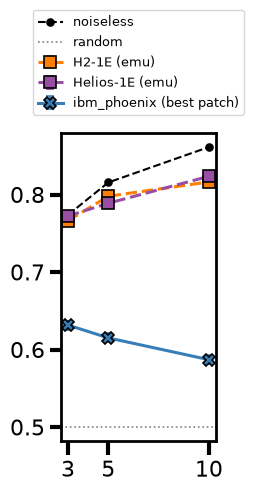

In [19]:
mcm_r_panel("surface_d3",
                  {"H2-1E": ["20260820_0707"], "Helios-1E": ["20260306_1514", "20260306_1518"],
                   "ibm_phoenix": ["20260909_1631"]},
                  published={"H2-1E": [0.980, 0.947, 0.885], "Helios-1E": [1.002, 0.919, 0.905],
                             "ibm_phoenix": [0.490, 0.372, 0.249]},
                  name="fig8b_mcm_rovl_surface_d3.pdf")

### Fig. 8c - surface code $d = 5$ (25 data qubits), MCM

surface_d5: r with 1 sigma shot noise, and n_sigma above random; published r_ovl below each row
                    device  shots               p=3               p=5              p=10
                      H2-1     50  0.673+-0.013 (12s)  0.688+-0.011 (13s)  0.709+-0.012 (14s)
           published r_ovl                    0.759             0.625             0.611
                  Helios-1     50  0.735+-0.013 (16s)  0.748+-0.011 (17s)  0.752+-0.015 (17s)
           published r_ovl                    1.030             0.826             0.736
                 Helios-1E    500  0.696+-0.005 (43s)  0.727+-0.004 (50s)  0.743+-0.004 (53s)
           published r_ovl                    0.857             0.757             0.710
  ibm_phoenix (best patch)   1000  0.548+-0.003 (15s)  0.564+-0.004 (20s)  0.552+-0.004 (16s)
           published r_ovl                    0.210             0.211             0.153
                 noiseless                    0.731             0.797             0.843


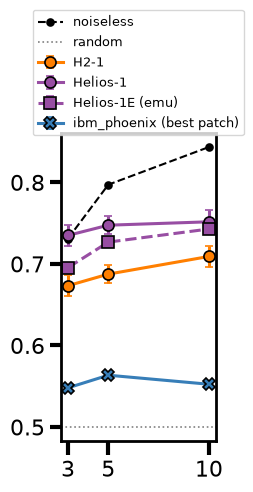

In [20]:
mcm_r_panel("surface_d5",
                  {"H2-1": ["20260820_0736"], "Helios-1": ["20260825_1229"], "Helios-1E": ["20260309_1203"],
                   "ibm_phoenix": ["20260909_1619"]},
                  published={"H2-1": [0.759, 0.625, 0.611], "Helios-1": [1.030, 0.826, 0.736],
                             "Helios-1E": [0.857, 0.757, 0.710], "ibm_phoenix": [0.210, 0.211, 0.153]},
                  name="fig8c_mcm_rovl_surface_d5.pdf")

## 10. Fig. 9a - both frames of the benchmark against both memories, in one campaign

A **campaign** is one session in which the same surface-code patches of `ibm_phoenix` were measured four ways on
the same physical qubits: the LR-QAOA benchmark in the **Z frame** (the checks as $Z\cdots Z$ terms, kind `mcm`) and
in the **X frame** (the same algorithm conjugated by $H$ on every data qubit, kind `mcm_x`), and the surface-code
memory holding $|0\rangle_L$ and $|+\rangle_L$ ($R$ rounds, both bases). One LR-QAOA layer is one syndrome-extraction
round, so each patch gives a paired point at every $p = R$.

**Fig. 9a** follows the single patch that held $|+\rangle_L$ longest from the first depth to the last, in every
sitting that ran both frames, one marker and colour per sitting: $r_{\rm ovl}(p)$ against $P_L^X(R = p)$, the X
frame solid and the Z frame of the same patch faint and dashed. One patch across the campaigns means the panel
reads as the chip drifting under a fixed placement, and the curve the benchmark traces into a logical error rate
is the same curve on every day.

Behind it, in grey, is **every other patch of every sitting at every depth**. The highlighted trajectories are a
slice through that cloud, and the cloud is the point: a benchmark score maps onto a logical error rate across the
chip and across the fortnight, not only along one placement.

Only sessions that ran **both** frames are shown, so that every point of both panels rests on the same four
measurements; the campaigns that ran the Z frame alone are left out.

Both panels are one column wide, as the paper sets them.

The cell prints Spearman $\rho$ for each frame against each memory, and writes the table of section 10b.

20260930_0919: 11 surface_d3 patches, depths [3], mcm 20260930_091918_ibm_phoenix_surface_code_mcm.json, memory 20260930_095545_ibm_phoenix_surface_code_memory.json, mcm_x 20260930_091918_ibm_phoenix_surface_code_mcm_x.json
   09-22: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-23 07h: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-23 16h: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-24: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-26 08h: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-26 13h: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-28 08h: 11 patches, depths [1, 2, 3, 5, 7, 10], frames X+Z
   09-28 09h: 11 patches, depths [1, 2, 3, 5, 7, 10, 12, 15, 20], frames X+Z
   09-28 13h: 11 patches, depths [3], frames X+Z
   09-29 10h: 11 patches, depths [3], frames X+Z
   09-29 11h: 11 patches, depths [3], frames X+Z
   09-30: 11 patches, depths [3], frames X+Z


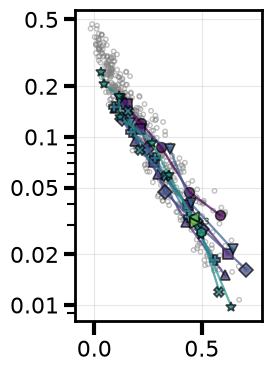


20260930_0919: rho against the memory, over p = R >= 2
   P_L^Z vs r_ovl^Z: +0.88
   P_L^Z vs r_ovl^X: +0.72
   P_L^X vs r_ovl^Z: +0.73
   P_L^X vs r_ovl^X: +0.72


In [26]:
import json
import re
from datetime import datetime

from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from qecbench import memory as mem
from qecbench.analysis import load_results
from scipy.stats import rankdata, spearmanr

# the sittings the paper's Fig. 9a draws (benchmark stamps); None takes every sitting in data/
SITTINGS = ["20260922_1326", "20260923_0715", "20260923_1635", "20260924_0804", "20260926_0857", "20260926_1311",
            "20260928_0812", "20260928_0900", "20260928_1313", "20260929_1054", "20260929_1102", "20260930_0919"]
CAMPAIGN = "20260930_0919"   # the reference sitting; None: the newest of SITTINGS
DISTANCE = 3
N_BEST, N_WORST = 3, 3
SURFACE = RESULTS / "ibm_phoenix" / "surface_code"
TILE_FRAME = {"Z": "#2f6f9f", "X": "#b8560f"}


WINDOW_HOURS = 3          # a benchmark run and a memory run are the same sitting only this close in time


def when(path):
    return datetime.strptime(re.match(r"\d{8}_\d{4}", path.name).group(0), "%Y%m%d_%H%M")


def anchors_of(path):
    # the placements a file covers, read straight from it: cheap, and enough to tell two scans apart
    return {(r["benchmark"]["instance"]["code"]["name"], min(r["parameters"]["data_qubits"]))
            for r in json.loads(path.read_text())["results"]}


def sittings():
    # {stamp: {kind: file}}, one entry per benchmark run, matched one-to-one with its memory run.
    # Nearness in time alone mismatches runs: a day can hold two benchmark runs and three memory
    # runs, and the file closest in time may be the one that scanned different placements. Pairs are
    # ranked by how many placements they share and then by how close they sit in time, and each run
    # is used at most once, so one sitting can never stand in for two.
    files = {k: sorted((SURFACE / k).glob("*.json")) for k in ("mcm", "mcm_x", "memory")}
    covers = {f: anchors_of(f) for group in files.values() for f in group}
    x_frame = {when(f): f for f in files["mcm_x"]}
    pairs = []
    for b in files["mcm"]:
        for m in files["memory"]:
            gap = abs((when(b) - when(m)).total_seconds())
            shared = len({a for _, a in covers[b]} & {a for _, a in covers[m]})
            if gap <= WINDOW_HOURS * 3600 and shared:
                pairs.append((-shared, gap, b, m))
    used_b, used_m, out = set(), set(), {}
    for _, _, b, m in sorted(pairs, key=lambda t: (t[0], t[1], t[2].name, t[3].name)):
        if b in used_b or m in used_m:
            continue
        used_b.add(b)
        used_m.add(m)
        got = {"mcm": b, "memory": m}
        if when(b) in x_frame:
            got["mcm_x"] = x_frame[when(b)]
        out[when(b).strftime("%Y%m%d_%H%M")] = got
    return dict(sorted(out.items()))


def campaigns():
    # the sittings that ran the benchmark in both frames as well as the memory
    return {k: got for k, got in sittings().items() if len(got) == 3}


def one_per_day(every):
    # the last complete sitting of each day: a table column per day, narrow enough for two columns
    return {max(k for k in every if k[:8] == day): every[max(k for k in every if k[:8] == day)]
            for day in sorted({k[:8] for k in every})}


def session_label(stamp, every):
    # the day, and the hour too when that day holds more than one sitting
    same_day = [k for k in every if k[:8] == stamp[:8]]
    return f"{stamp[4:6]}-{stamp[6:8]}" + (f" {stamp[9:11]}h" if len(same_day) > 1 else "")


def campaign_data(day, files):
    frames = {"Z": load_results(RESULTS, "ibm_phoenix", kind="mcm", files={files["mcm"].name})}
    if "mcm_x" in files:
        frames["X"] = load_results(RESULTS, "ibm_phoenix", kind="mcm_x", files={files["mcm_x"].name})
    logical = mem.load_results(RESULTS, "ibm_phoenix", files={files["memory"].name})
    patches = sorted((q for q in frames["Z"] if q in logical and all(q in f for f in frames.values())
                      and q.code.info.get("distance") == DISTANCE), key=lambda q: min(q.data_qubits))
    depths = sorted(set.intersection(*(set(frames["Z"][q]) & set(logical[q]["Z"]) for q in patches)))
    return frames, logical, patches, depths


sessions = {k: got for k, got in campaigns().items() if SITTINGS is None or k in SITTINGS}
day = CAMPAIGN or max(sessions)
frames, logical, patches, depths = campaign_data(day, sessions[day])
print(f"{day}: {len(patches)} surface_d{DISTANCE} patches, depths {depths}, "
      f"{', '.join(k + ' ' + v.name for k, v in sessions[day].items())}")

by_session = {st: campaign_data(st, f) for st, f in sittings().items()
              if "mcm_x" in f and (SITTINGS is None or st in SITTINGS)}
by_session = {st: got for st, got in by_session.items() if len(got[2]) >= 4}   # too few shared patches says nothing
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*","h", "H", "<", ">", "1", "2", "3", "4"]
MIN_DEPTH = 2                                     # p = R = 1 is a single round, where the memory barely errs
deep_of = lambda ds: [p for p in ds if p >= MIN_DEPTH]
label_of = lambda st: session_label(st, by_session)
for st, (fr, _, qs, ds) in sorted(by_session.items()):
    print(f"   {label_of(st)}: {len(qs)} patches, depths {ds}, frames {'+'.join(sorted(fr))}")

# Fig. 9b: the patch that held |+>_L longest in the reference campaign, followed through every campaign
rank = {q: np.mean([sorted(patches, key=lambda o: logical[o]["X"][p]["rate"]).index(q) + 1
                    for p in deep_of(depths)]) for q in patches}
star = min(patches, key=lambda q: rank[q])
shown = [st for st, (_, _, qs, _) in sorted(by_session.items()) if star in qs]
fig_b, ax = plt.subplots(figsize=(3, 4))       # one column wide, as the other Fig. 9 panels
# every other patch of every sitting, in grey: the cloud the highlighted patch is drawn from, and the
# reason a single trajectory is worth following - the relation holds across the chip, not just along it
ax.scatter([by_session[st][0]["X"][q][p]["r_ovl"] for st in by_session
            for q in by_session[st][2] for p in deep_of(by_session[st][3])],
           [by_session[st][1][q]["X"][p]["rate"] for st in by_session
            for q in by_session[st][2] for p in deep_of(by_session[st][3])],
           s=10, facecolors="none", edgecolors="gray", alpha=0.5, zorder=0, label="every patch")
colours = plt.get_cmap("viridis")(np.linspace(0, 0.82, len(shown)))
for j, st in enumerate(shown):
    fr, lg, _, ds = by_session[st]
    ds = deep_of(ds)
    pl = [lg[star]["X"][p]["rate"] for p in ds]
    ax.plot([fr["X"][star][p]["r_ovl"] for p in ds], pl, "-", marker=MARKERS[j], color=colours[j], lw=1.6,
            ms=7, zorder=3, label=label_of(st), markeredgecolor="black", alpha=0.7)
    if st == shown[-1]:                            # depths marked once, on the newest campaign
        for p, xv, yv in zip(ds, [fr["X"][star][p]["r_ovl"] for p in ds], pl):
            ax.annotate(f"{p}", (xv, yv), textcoords="offset points", xytext=(6, 1), fontsize=7, color="0.25",
                        ha="left", va="center")
ax.set(yscale="log")
ax.margins(x=0.10)                                 # room for the depth labels at either end
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0), numticks=12))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.grid(alpha=0.3)
# naming all the sittings costs more room than it is worth here: colour already runs with the calendar
# ax.legend(handles=[Line2D([], [], ls="", marker="o", ms=6, color="0.75",
#                           label="all patches"),
#                    Line2D([], [], ls="-", marker="o", ms=7, lw=1.6, color=colours[-1],markeredgecolor="black",
#                           label=f"best patch"),
#                    Line2D([], [], ls="--", lw=0.9, color=colours[-1], alpha=0.55, label="Z frame")],
#            frameon=True)
if SHOW_LABELS:
    ax.set(xlabel=r"$r_{\rm ovl}(p)$", ylabel=r"$P_L^X(R = p)$")
fig_b.tight_layout()
fig_b.savefig(FIGURES / "fig9a_best_patches.pdf", transparent=True, bbox_inches="tight")
plt.show()


def pooled(values, basis, ps, patches_, logical_):
    # rho over the depths p = R >= 2, ranking the patches within each depth (larger value = worse patch)
    xs, ys = [], []
    for p in ps:
        xs += list(rankdata([values(q, p) for q in patches_]))
        ys += list(rankdata([logical_[q][basis][p]["rate"] for q in patches_]))
    return spearmanr(xs, ys)[0]


deep = [p for p in depths if p >= 2]
print(f"\n{day}: rho against the memory, over p = R >= 2")
for basis in ("Z", "X"):
    for frame in ("Z", "X"):
        rho = pooled(lambda q, p, f=frame: -frames[f][q][p]["r_ovl"], basis, deep, patches, logical)
        print(f"   P_L^{basis} vs r_ovl^{frame}: {rho:+.2f}")

### 10b. One patch, every sitting - is the decay a property of the patch or of the day?

The panel above is one sitting and every patch; this one is one patch and every sitting. The same placement is
followed through each session that ran both frames, faint lines for the individual days and the heavy line for
the mean over sittings in both frames, with bars for the standard deviation over those sittings. Short bars mean
the decay is a property of the patch and the benchmark is measuring something the chip keeps from day to day; where
they are long, the day matters, and their length is the ceiling on how well any single run can speak for another.
The bars are that day-to-day spread, not an uncertainty on the mean, which is smaller by a further root-seven.

The axis is the raw approximation ratio $r$, not $r_{\rm ovl}$, so the two references it sits between are drawn:
the noiseless circuit above (dashed, which itself rises with $p$ because deeper LR-QAOA finds a better state) and
random guessing below (dotted). What $r_{\rm ovl}$ reports is where a curve falls between those two lines, and
keeping them visible shows how little of that band is left by $p = 10$.

`TRACK_PATCH` picks the placement by its lowest data qubit; `None` follows the one Fig. 9b highlights.

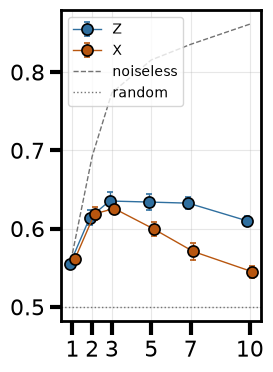

patch @63 over 8 sittings (09-22 to 09-28 09h)
    frame              p=1             p=2             p=3             p=5             p=7            p=10
        Z     0.555 +-0.004    0.614 +-0.010    0.635 +-0.011    0.634 +-0.010    0.633 +-0.008    0.610 +-0.007
        X     0.561 +-0.006    0.619 +-0.008    0.626 +-0.008    0.600 +-0.009    0.571 +-0.011    0.545 +-0.007
noiseless            0.568           0.692           0.774           0.816           0.835           0.861
   random            0.500           0.500           0.500           0.500           0.500           0.500

day-to-day spread as a fraction of the distance from random, (r - r_rand):
        Z               7%              8%              8%              7%              6%              6%
        X              10%              7%              6%              9%             16%             17%


In [ ]:
TRACK_PATCH = None                                 # e.g. 63; None takes the patch Fig. 9b follows
# the sittings the paper's Fig. 9b averages; None takes every sitting of Fig. 9a that ran the full sweep
TRACK_SITTINGS = ["20260922_1326", "20260923_0715", "20260923_1635", "20260924_0804", "20260926_0857", "20260926_1311",
                  "20260928_0812", "20260928_0900"]
SWEEP = [1, 2, 3, 5, 7, 10]                        # the depths a sitting needs when TRACK_SITTINGS is None
tracked = star if TRACK_PATCH is None else next(q for q in patches if min(q.data_qubits) == TRACK_PATCH)
shown_days = [st for st, (fr, _, qs, ds) in by_session.items() if tracked in qs and "X" in fr
              and (st in TRACK_SITTINGS if TRACK_SITTINGS is not None else set(SWEEP) <= set(ds))]
ps_e = sorted(set.intersection(*(set(by_session[st][0]["Z"][tracked]) for st in shown_days)))

fig_e, ax = plt.subplots(figsize=(3, 4))       # one column wide, as the other Fig. 9 panels
summary = lambda st, frame, p: by_session[st][0][frame][tracked][p]
# bars are the standard deviation over the sittings: how much the day moves this patch, not an error on the mean
for frame, dodge in (("Z", -0.12), ("X", 0.12)):   # a nudge apart, or the two sets of bars overlap
    curves = np.array([[summary(st, frame, p)["r"] for p in ps_e] for st in shown_days])
    ax.errorbar(np.array(ps_e) + dodge, curves.mean(axis=0), yerr=curves.std(axis=0), fmt="-o",
                color=TILE_FRAME[frame], lw=1, ms=8, capsize=2.5, elinewidth=1, zorder=3,markeredgecolor="black",
                label=f"{frame}")
# r runs between two fixed references, so draw them: random guessing below, the noiseless circuit above
ideal = [summary(shown_days[-1], "Z", p)["r_ideal"] for p in ps_e]
rand = summary(shown_days[-1], "Z", ps_e[0])["r_rand"]
ax.plot(ps_e, ideal, "--", color="0.45", lw=1, zorder=2, label="noiseless")
ax.axhline(rand, ls=":", color="0.45", lw=1, zorder=2, label="random")
ax.set_xticks(ps_e)
ax.get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.grid(alpha=0.3)
handles, labels = ax.get_legend_handles_labels()   # the frames first, the two references after them
order = sorted(range(len(labels)), key=lambda k: labels[k] in ("noiseless", "random"))
ax.legend([handles[k] for k in order], [labels[k] for k in order],
          fontsize=10, frameon=True)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel="$r$")
fig_e.tight_layout()
fig_e.savefig(FIGURES / "fig9b_one_patch_over_days.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"patch @{min(tracked.data_qubits)} over {len(shown_days)} sittings "
      f"({label_of(shown_days[0])} to {label_of(shown_days[-1])})")
print(f"{'frame':>9} " + "".join(f"{'p=' + str(p):>16}" for p in ps_e))
for frame in ("Z", "X"):
    cells_e = [[summary(st, frame, p)["r"] for st in shown_days] for p in ps_e]
    print(f"{frame:>9} " + "".join(f"{np.mean(c):>9.3f} +-{np.std(c):>4.3f}" for c in cells_e))
print(f"{'noiseless':>9} " + "".join(f"{v:>16.3f}" for v in ideal))
print(f"{'random':>9} " + "".join(f"{rand:>16.3f}" for _ in ps_e))
print("\nday-to-day spread as a fraction of the distance from random, (r - r_rand):")
for frame in ("Z", "X"):
    cv = [np.std([summary(st, frame, p)["r"] for st in shown_days])
          / (np.mean([summary(st, frame, p)["r"] for st in shown_days]) - rand) for p in ps_e]
    print(f"{frame:>9} " + "".join(f"{v:>16.0%}" for v in cv))

### How far the benchmark still says something: $d = 3$ out to $p = 20$

The sweeps above stop at $p = 10$, where both frames still sit well above random. This panel takes the deepest run
on the chip - $d = 3$ only, so the depth is affordable - and follows it to $p = 20$ in both frames, every patch
faint and their median heavy, against the same two references as 10e.

It answers a question the shallow sweeps cannot: where the benchmark stops being a measurement. Once a patch's $r$
is within the shot noise of the random line it carries no information about that patch however many shots are
spent, so the depth at which the median crosses is the honest end of the useful range.

`DEEP_RUN` names the run by its stamp; `None` takes whichever both-frames run reaches the deepest $p$.

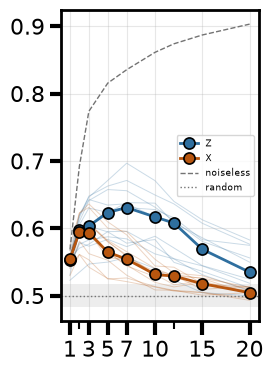

20260928_0900: 11 surface_d3 patches, depths [1, 2, 3, 5, 7, 10, 12, 15, 20]
                 p=1     p=2     p=3     p=5     p=7    p=10    p=12    p=15    p=20
   Z median    0.553   0.597   0.603   0.623   0.631   0.617   0.608   0.569   0.535
   X median    0.554   0.595   0.593   0.565   0.554   0.531   0.529   0.518   0.504
  noiseless    0.568   0.692   0.774   0.816   0.835   0.861   0.874   0.887   0.903
     random    0.500   0.500   0.500   0.500   0.500   0.500   0.500   0.500   0.500

patches still clear of random by 3 sigma (0.017 in r):
          Z       11      11      11      11      11      11      11      10       8   of 11
          X       11      11      11      11      11       8       6       6       0   of 11


In [ ]:
DEEP_RUN = "20260928_0900"                         # the run the paper draws; None takes the deepest both-frames run
deep_candidates = {}
for x_file in sorted((SURFACE / "mcm_x").glob("*.json")):
    z_file = SURFACE / "mcm" / x_file.name.replace("_mcm_x", "_mcm")
    if z_file.exists():
        deep_candidates[x_file.name[:13]] = (z_file, x_file)
if DEEP_RUN is not None:
    deep_stamp = next(k for k in deep_candidates if k.startswith(DEEP_RUN))
else:
    reach = {}
    for k, (z_file, _) in deep_candidates.items():
        got = json.loads(z_file.read_text())["results"]
        reach[k] = max(r["parameters"]["depth"] for r in got
                       if r["benchmark"]["instance"]["code"]["name"] == f"surface_d{DISTANCE}")
    deep_stamp = max(reach, key=lambda k: (reach[k], k))
deep_files = deep_candidates[deep_stamp]
deep = {"Z": load_results(RESULTS, "ibm_phoenix", kind="mcm", files={deep_files[0].name}),
        "X": load_results(RESULTS, "ibm_phoenix", kind="mcm_x", files={deep_files[1].name})}
deep_patches = sorted((q for q in deep["Z"] if q in deep["X"] and q.code.info.get("distance") == DISTANCE),
                      key=lambda q: min(q.data_qubits))
ps_f = sorted(set.intersection(*(set(deep["Z"][q]) & set(deep["X"][q]) for q in deep_patches)))

fig_f, ax = plt.subplots(figsize=(3, 4))       # one column wide, as the other Fig. 9 panels
for frame in ("Z", "X"):
    for q in deep_patches:
        ax.plot(ps_f, [deep[frame][q][p]["r"] for p in ps_f], "-", color=TILE_FRAME[frame], lw=0.7, alpha=0.25,
                zorder=1)
    med = [np.median([deep[frame][q][p]["r"] for q in deep_patches]) for p in ps_f]
    ax.plot(ps_f, med, "-o", color=TILE_FRAME[frame], lw=2, ms=8, zorder=3, label=f"{frame}", markeredgecolor="black")
ideal_f = [deep["Z"][deep_patches[0]][p]["r_ideal"] for p in ps_f]
rand_f = deep["Z"][deep_patches[0]][ps_f[0]]["r_rand"]
band = 3 * np.median([deep["Z"][q][ps_f[0]]["r_rand_std"] for q in deep_patches])
ax.plot(ps_f, ideal_f, "--", color="0.45", lw=1, zorder=2, label="noiseless")
ax.axhline(rand_f, ls=":", color="0.45", lw=1, zorder=2, label="random")
ax.axhspan(rand_f - band, rand_f + band, color="0.45", alpha=0.12, lw=0, zorder=0)
ax.set_xticks([p for p in ps_f if p in (1, 3, 5, 7, 10, 15, 20)])   # the rest collide at this width
ax.set_xticks(ps_f, minor=True)
ax.get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.grid(alpha=0.3)
ax.legend(fontsize=6.5, title_fontsize=7, frameon=True)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel="$r$")
fig_f.tight_layout()
fig_f.savefig(FIGURES / "fig9f_deep_sweep_d3.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"{deep_stamp}: {len(deep_patches)} surface_d{DISTANCE} patches, depths {ps_f}")
print(f"{'':>11} " + "".join(f"{'p=' + str(p):>8}" for p in ps_f))
for frame in ("Z", "X"):
    med = [np.median([deep[frame][q][p]["r"] for q in deep_patches]) for p in ps_f]
    print(f"{frame + ' median':>11} " + "".join(f"{v:>8.3f}" for v in med))
print(f"{'noiseless':>11} " + "".join(f"{v:>8.3f}" for v in ideal_f))
print(f"{'random':>11} " + "".join(f"{rand_f:>8.3f}" for _ in ps_f))
print(f"\npatches still clear of random by 3 sigma ({band:.3f} in r):")
for frame in ("Z", "X"):
    alive = [sum(deep[frame][q][p]["r"] > rand_f + band for q in deep_patches) for p in ps_f]
    print(f"{frame:>11} " + "".join(f"{v:>8}" for v in alive) + f"   of {len(deep_patches)}")

### 9c. Both memories against the number of rounds

The same runs as 10g, now against $R$ rather than against each other: for each logical state, the median over runs
of each run's median over the patches, with bars covering the 16th to 84th percentile of the runs. The bars are the
day-to-day spread of the chip, not an uncertainty on the median - with 14 runs the median itself is far better
determined than the bars suggest.

Read it together with 10g. The two heavy curves lying on top of each other is the statement that the device has no
preferred basis **on the whole**, while 10g shows the individual patches scattered widely either side of the
diagonal. Both are true at once: the asymmetry is a property of each patch, not of the chip, and it averages away.
That is also why the comparison has to be made patch by patch - the median of $P_L^Z$ and the median of $P_L^X$
over a set of patches are medians of *different* patches, and their ratio is not a basis asymmetry.

The spread of the faint lines at fixed $R$ is the day-to-day drift of the chip, the same quantity Fig. 9e measures
in the benchmark.

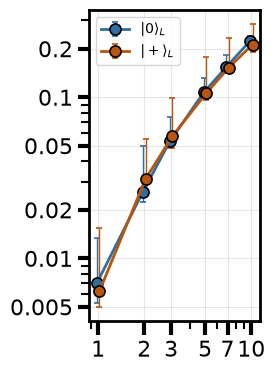

median over runs of each run's median over patches
                             R=1      R=2      R=3      R=5      R=7     R=10
                 |0>_L    0.0070   0.0259   0.0532   0.1072   0.1537   0.2230
                 |+>_L    0.0063   0.0311   0.0575   0.1064   0.1530   0.2125
  ratio of the medians      0.89     1.20     1.08     0.99     1.00     0.95
paired, patch by patch      1.00     1.01     1.03     0.99     1.01     0.98   <- the honest comparison


In [ ]:
ROUNDS_SHOWN = [1, 2, 3, 5, 7, 10]
ROUND_SHOWN = 3
# the memory runs the paper's Fig. 9c pools (file stamps); None takes every run in data/
MEMORY_RUNS = ["20260914_0941", "20260918_1224", "20260921_0843", "20260922_0955", "20260922_1529", "20260923_0715",
               "20260923_1635", "20260924_0812", "20260925_0646", "20260926_0825", "20260926_0902", "20260926_1311",
               "20260928_0812", "20260928_0849"]
mem_runs = {}
for path in sorted((SURFACE / "memory").glob("*.json")):
    got = mem.load_results(RESULTS, "ibm_phoenix", files={path.name})
    qs = [q for q in got if q.code.info.get("distance") == DISTANCE
          and ROUND_SHOWN in got[q]["Z"] and ROUND_SHOWN in got[q]["X"]]
    if len(qs) >= 4:
        mem_runs[when(path).strftime("%Y%m%d_%H%M")] = (got, sorted(qs, key=lambda q: min(q.data_qubits)))
mem_runs = {st: got for st, got in mem_runs.items() if MEMORY_RUNS is None or st in MEMORY_RUNS}

fig_h, ax = plt.subplots(figsize=(3, 4))       # one column wide, as the other Fig. 9 panels
per_run = {basis: [] for basis in ("Z", "X")}
for st, (got, qs) in mem_runs.items():
    usable = [q for q in qs if all(r in got[q]["Z"] and r in got[q]["X"] for r in ROUNDS_SHOWN)]
    if not usable:
        continue
    for basis in ("Z", "X"):
        per_run[basis].append([np.median([got[q][basis][r]["rate"] for q in usable]) for r in ROUNDS_SHOWN])
# the bars are the 16th-84th percentile over the runs: the day-to-day spread, not an uncertainty on the median
for basis, dodge in (("Z", 0.98), ("X", 1.02)):    # a nudge apart, or the two sets of bars overlap
    stack = np.array(per_run[basis])
    middle = np.median(stack, axis=0)
    lo_hi = np.abs(np.percentile(stack, [16, 84], axis=0) - middle)
    ax.errorbar(np.array(ROUNDS_SHOWN) * dodge, middle, yerr=lo_hi, fmt="-o", color=TILE_FRAME[basis], lw=2,
                ms=8, capsize=2.5, elinewidth=1, zorder=3,markeredgecolor="black",
                label=rf"$|0\rangle_L$" if basis == "Z" else rf"$|+\rangle_L$")
ax.set(xscale="log", yscale="log")
ax.set_xticks(ROUNDS_SHOWN)
for axis in (ax.get_xaxis(), ax.get_yaxis()):
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.get_xaxis().set_minor_formatter(NullFormatter())
ax.get_yaxis().set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0), numticks=12))
ax.get_yaxis().set_minor_formatter(NullFormatter())
ax.grid(alpha=0.3)
ax.legend(fontsize=10, title_fontsize=7, frameon=True, loc="upper left")
if SHOW_LABELS:
    ax.set(xlabel="$R$", ylabel="$P_L$")
fig_h.tight_layout()
fig_h.savefig(FIGURES / "fig9c_memory_vs_rounds.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"median over runs of each run's median over patches")
print(f"{'':>22} " + "".join(f"{'R=' + str(r):>9}" for r in ROUNDS_SHOWN))
for basis in ("Z", "X"):
    print(f"{('|0>_L' if basis == 'Z' else '|+>_L'):>22} "
          + "".join(f"{v:>9.4f}" for v in np.median(per_run[basis], axis=0)))
print(f"{'ratio of the medians':>22} "
      + "".join(f"{a / b:>9.2f}" for a, b in zip(np.median(per_run["X"], axis=0), np.median(per_run["Z"], axis=0))))
paired = []
for r in ROUNDS_SHOWN:
    got_all = [got[q]["X"][r]["rate"] / got[q]["Z"][r]["rate"]
               for got, qs in mem_runs.values() for q in qs
               if r in got[q]["Z"] and r in got[q]["X"] and got[q]["Z"][r]["rate"] > 0]
    paired.append(np.median(got_all))
print(f"{'paired, patch by patch':>22} " + "".join(f"{v:>9.2f}" for v in paired) + "   <- the honest comparison")

### Fig. 9d - how few shots the benchmark needs

The benchmark is worth running only if it is much cheaper than the experiment it stands in for, so: how far can its
shots be cut before it stops ranking the patches the way the memory does? The shots actually taken (1000 per
circuit) are resampled down to a budget $S$, $r_{\rm ovl}$ is recomputed from the resampled counts, and the ranking
question is asked again; the memory keeps all 4000 of its shots throughout. Two protocols are compared at equal
total cost: the **full sweep** over $p \in \{2, 3, 5, 7, 10\}$ scored against $P_L^X(R = p)$, and **one depth
only**, $p = 3$, scored against the memory at every $R$ - a single depth predicts every round count, so matching
$p$ to $R$ buys nothing.

The grey line is what the memory experiment itself costs on the same patches. Resampling reuses the 1000 shots
already taken, so each point carries their noise as well as the budget's: the curves slightly understate a real
short run, and the measured value (the star) sits above the resampled one at the same $S$.

Cached in `data/shot_budget/benchmark_shot_budget.json`; delete that file or set `RECOMPUTE_SHOTS = True` to
recompute.

read data/shot_budget/benchmark_shot_budget.json


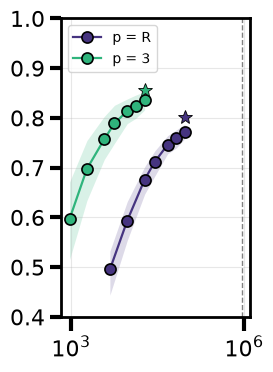

                 p = R: 0.75 at 47.5k shots (19x cheaper than the memory), 90% of the 0.80 the full 95k shots give
                 p = 3: 0.79 at 5.7k shots (160x cheaper than the memory), 90% of the 0.86 the full 19k shots give


In [ ]:
RECOMPUTE_SHOTS = False
# the sittings the cached curves were computed from, used on a recompute; None takes every both-frames sitting
SHOT_SITTINGS = ["20260922_1326", "20260923_0715", "20260923_1635", "20260924_0804", "20260926_0857", "20260926_1311",
                 "20260928_0812", "20260928_0900"]
SHOT_GRID = [50, 100, 200, 300, 500, 700, 1000]
TRIALS = 200
CACHE_SHOTS = ROOT / "data" / "shot_budget" / "benchmark_shot_budget.json"
N_CIRCUITS = 19                                    # placements submitted per depth in one session
MEMORY_SHOTS = 912_000                             # both bases, six round counts, 38 circuits x 4000 shots

if CACHE_SHOTS.exists() and not RECOMPUTE_SHOTS:
    curves = json.loads(CACHE_SHOTS.read_text())
    print(f"read {CACHE_SHOTS.relative_to(ROOT)}")
else:
    from qecbench.analysis import bitstring_energies, instance_from_record, random_baseline
    from qecbench.lrqaoa import ideal_r

    def shot_cells(depth_filter):
        # per session and depth: the observed energy distribution of each patch, and its P_L^X at every R
        out = {}
        for st, files_ in sittings().items():
            if "mcm_x" not in files_ or (SHOT_SITTINGS is not None and st not in SHOT_SITTINGS):
                continue
            logical_ = mem.load_results(RESULTS, "ibm_phoenix", files={files_["memory"].name})
            for record in json.loads(files_["mcm_x"].read_text())["results"]:
                q = instance_from_record(record)
                p_ = record["parameters"]["depth"]
                if q is None or q.code.info.get("distance") != DISTANCE or q not in logical_ or not depth_filter(p_):
                    continue
                counts = record["samples"]
                w = np.array(list(counts.values()), float)
                out.setdefault((st, p_), []).append(
                    (bitstring_energies(counts, q.hamiltonian), w / w.sum(), q.optimal_energy(), q.max_energy(),
                     random_baseline(q, 1000)[0], ideal_r(q, p_),
                     {R: logical_[q]["X"][R]["rate"] for R in logical_[q]["X"]}))
        return out

    rng = np.random.default_rng(7)

    def resampled(cell, shots):
        got = []
        for energies, weights, e_opt, e_max, r_rand, r_ideal, _ in cell:
            k = rng.multinomial(shots, weights) if shots else weights
            r = ((energies * k).sum() / k.sum() - e_max) / (e_opt - e_max)
            got.append((r - r_rand) / (r_ideal - r_rand))
        return -np.array(got)                      # oriented so that larger means worse, as the table has it

    def curve(cells_, against, shots):
        # mean rho over the session-depth cells, for one resampling trial
        got = []
        for (st, p_), cell in cells_.items():
            score = resampled(cell, shots)
            got += [spearmanr(score, [c[6][R] for c in cell])[0] for R in against(p_)]
        return float(np.mean(got))

    depths_all = [2, 3, 5, 7, 10]
    protocols = {"p = R": (shot_cells(lambda p_: p_ in depths_all), lambda p_: [p_], len(depths_all)),
                 "p = 3": (shot_cells(lambda p_: p_ == 3), lambda p_: depths_all, 1)}
    curves = {}
    for name, (cells_, against, n_depths) in protocols.items():
        rows_ = []
        for shots in SHOT_GRID:
            trials = [curve(cells_, against, shots) for _ in range(TRIALS)]
            rows_.append({"shots": shots, "total": N_CIRCUITS * n_depths * shots,
                          "rho": float(np.median(trials)), "lo": float(np.percentile(trials, 10)),
                          "hi": float(np.percentile(trials, 90))})
        curves[name] = {"points": rows_, "measured": curve(cells_, against, None),
                        "measured_total": N_CIRCUITS * n_depths * 1000}
        print(f"{name:>22}: measured rho {curves[name]['measured']:.2f} at "
              f"{curves[name]['measured_total'] / 1000:.0f}k shots")
    CACHE_SHOTS.parent.mkdir(parents=True, exist_ok=True)
    CACHE_SHOTS.write_text(json.dumps(curves, indent=1))
    print(f"written to {CACHE_SHOTS.relative_to(ROOT)}")

fig_c, ax = plt.subplots(figsize=(3,4))       # Fig. 9c, one column wide
shot_colour = {"p = R": plt.get_cmap("viridis")(0.15),
               "p = 3": plt.get_cmap("viridis")(0.65)}
for name, got in curves.items():
    xs = [row["total"] for row in got["points"]]
    ax.fill_between(xs, [row["lo"] for row in got["points"]], [row["hi"] for row in got["points"]],
                    color=shot_colour[name], alpha=0.18, lw=0)
    ax.plot(xs, [row["rho"] for row in got["points"]], "-o", color=shot_colour[name], lw=1.6, ms=8, label=name, markeredgecolor="black")
    ax.plot(got["measured_total"], got["measured"], "*", color=shot_colour[name], ms=10, mew=0.6,
            zorder=4, markeredgecolor="black")
ax.axvline(MEMORY_SHOTS, color="0.5", ls="--", lw=1)
ax.set(xscale="log", ylim=(0.4, 1.0))
ax.grid(alpha=0.3)
ax.legend(fontsize=10, frameon=True)
if SHOW_LABELS:
    ax.set(xlabel="shots in the benchmark", ylabel=r"Spearman $\rho$ against $P_L^X$")
fig_c.tight_layout()
fig_c.savefig(FIGURES / "fig9d_shot_budget.pdf", transparent=True, bbox_inches="tight")
plt.show()

for name, got in curves.items():
    cheapest = next(row for row in got["points"] if row["rho"] >= 0.9 * got["measured"])
    print(f"{name:>22}: {cheapest['rho']:.2f} at {cheapest['total'] / 1000:.1f}k shots "
          f"({MEMORY_SHOTS / cheapest['total']:.0f}x cheaper than the memory), "
          f"90% of the {got['measured']:.2f} the full {got['measured_total'] / 1000:.0f}k shots give")

### 10. Every predictor against both memories, in one panel

Table 10b holds the same numbers session by session; this is the summary the table cannot be, over the sittings
that ran **both** frames. Each predictor gets a bar per memory: the **median** over those sittings of its Spearman
$\rho$ against $P_L$, with bars running to the lower and upper quartile. Eight sittings are too few for a mean and
a standard deviation to describe a skewed spread, and a symmetric bar would reach past $\rho = 1$ for the best
predictors. Every predictor is oriented so larger means worse, so a longer bar is a better predictor.

The error bars carry the part a single-column table hides: a predictor that is strong on average but swings from
sitting to sitting is not one to trust on the day, and that is the difference between the benchmark's two frames
and the calibration.

The panel is drawn from the **single depth** $p = R = 3$ - the one the shot-budget panel of Fig. 9c settles on -
because the sweep over depths is not what makes the benchmark work: every predictor does as well there as pooled
over all five depths, on a fifth of the shots. The cell prints both so the claim can be checked. The $Z$ frame
gains the most from the restriction, its deepest points being where its readout bias turns against it.

8 sittings: 09-22, 09-23 07h, 09-23 16h, 09-24, 09-26 08h, 09-26 13h, 09-28 08h, 09-28 09h

         predictor     vs P_L^Z, median [IQR]     vs P_L^X, median [IQR]  p=3 only: Z      X   worst
          -r_ovl^X       +0.78 [+0.72, +0.79]       +0.79 [+0.74, +0.84]         0.76   0.83   +0.58
          -r_ovl^Z       +0.70 [+0.65, +0.77]       +0.65 [+0.51, +0.70]         0.80   0.67   +0.47
          CZ error       +0.67 [+0.60, +0.85]       +0.59 [+0.55, +0.65]         0.66   0.54   +0.31
      data readout       +0.54 [+0.48, +0.62]       +0.40 [+0.29, +0.49]         0.60   0.46   +0.21


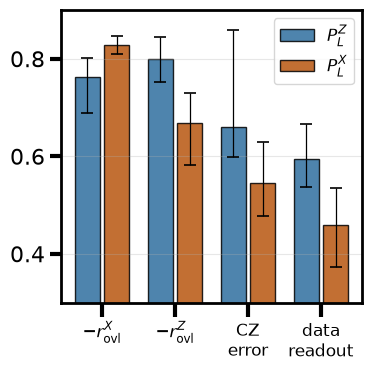

In [ ]:
def snapshot_for(path):
    # the newest calibration snapshot taken before that run started
    created = json.loads(path.read_text())["run"]["created"]
    taken = [(json.loads(s.read_text())["fetched_at"], s)
             for s in sorted((ROOT / "data" / "calibration" / "ibm_phoenix").glob("*_calibration.json"))]
    before = [s for t, s in taken if t <= created]
    return json.loads(before[-1].read_text()) if before else None
def calibration(patch, cal):
    one, two = cal["one_qubit"], cal["two_qubit"]
    q = lambda phys: one.get(str(phys)) or {}
    cz = [(two.get(f"{u}-{v}") or two.get(f"{v}-{u}") or {}).get("error", np.nan) for u, v in patch.couplers]
    anc = [q(a).get("mcm_readout_error", np.nan) for a in patch.ancillas]
    data = [q(d).get("readout_error", np.nan) for d in patch.data_qubits]
    sx = [q(x).get("sx_error", np.nan) for x in patch.qubits]
    return {"CZ error": np.nanmean(cz), "worst CZ": np.nanmax(cz), "sx error": np.nanmean(sx),
            "ancilla readout": np.nanmean(anc), "data readout": np.nanmean(data),
            "round budget": np.nansum(cz) + np.nansum(anc) + np.nansum(data)}


CAL_ROWS = ["CZ error", "data readout"]
FRAME_ROWS = {r"$-r_{\rm ovl}^{Z}$": "Z", r"$-r_{\rm ovl}^{X}$": "X"}
# the sittings the paper's Fig. 10 summarises; None takes every both-frames sitting
PREDICTOR_SITTINGS = ["20260922_1326", "20260923_0715", "20260923_1635", "20260924_0804", "20260926_0857", "20260926_1311",
                      "20260928_0812", "20260928_0900"]
both_frames = {k: got for k, got in campaigns().items() if PREDICTOR_SITTINGS is None or k in PREDICTOR_SITTINGS}
ONE_DEPTH = 3                                      # the single depth the cheap protocol of Fig. 9c would run
per_sitting = {name: {"Z": [], "X": []} for name in list(FRAME_ROWS) + CAL_ROWS}
at_one_depth = {name: {"Z": [], "X": []} for name in list(FRAME_ROWS) + CAL_ROWS}
for day_, files_ in both_frames.items():
    frames_, logical_, patches_, depths_ = campaign_data(day_, files_)
    cal = snapshot_for(files_["memory"])
    cals = {q: calibration(q, cal) for q in patches_} if cal else {}
    deep_ = [d for d in depths_ if d >= 2]
    for basis in ("Z", "X"):
        for name in list(FRAME_ROWS) + CAL_ROWS:
            values = ((lambda q, p_, f=FRAME_ROWS[name]: -frames_[f][q][p_]["r_ovl"]) if name in FRAME_ROWS
                      else (lambda q, p_, n=name: cals[q][n]))
            if name in CAL_ROWS and not cals:
                continue
            per_sitting[name][basis].append(pooled(values, basis, deep_, patches_, logical_))
            if ONE_DEPTH in depths_:
                at_one_depth[name][basis].append(pooled(values, basis, [ONE_DEPTH], patches_, logical_))
# the median and the quartiles, not the mean and its standard deviation: eight sittings are too few for a
# symmetric spread to mean much, and the distributions are skewed
middle_of = lambda values: np.median(values)
quartiles_of = lambda values: np.abs(np.percentile(values, [25, 75]) - np.median(values)).reshape(2, 1)
order = sorted(at_one_depth, key=lambda n: -np.mean([middle_of(at_one_depth[n][b]) for b in ("Z", "X")]))
print(f"{len(both_frames)} sittings: {', '.join(session_label(d, both_frames) for d in both_frames)}\n")
print(f"{'predictor':>18} {'vs P_L^Z, median [IQR]':>26} {'vs P_L^X, median [IQR]':>26} "
      f"{'p=3 only: Z':>12} {'X':>6} {'worst':>7}")
for name in order:
    z, x = np.array(per_sitting[name]["Z"]), np.array(per_sitting[name]["X"])
    label = name.replace(r"$-r_{\rm ovl}^{", "-r_ovl^").replace("}$", "")
    cell = lambda v: f"{np.median(v):+.2f} [{np.percentile(v, 25):+.2f}, {np.percentile(v, 75):+.2f}]"
    one = {b: np.median(at_one_depth[name][b]) if at_one_depth[name][b] else np.nan for b in ("Z", "X")}
    print(f"{label:>18} {cell(z):>26} {cell(x):>26} {one['Z']:>12.2f} {one['X']:>6.2f} "
          f"{min(z.min(), x.min()):>+7.2f}")

fig_i, ax = plt.subplots(figsize=(4,4))       # one column wide, as the other Fig. 9 panels
spots = np.arange(len(order))
for basis, offset, colour in (("Z", -0.2, "#2f6f9f"), ("X", 0.2, "#b8560f")):
    middle = [middle_of(at_one_depth[n][basis]) for n in order]
    spread = np.hstack([quartiles_of(at_one_depth[n][basis]) for n in order])
    ax.bar(spots + offset, middle, width=0.35, yerr=spread, color=colour, alpha=0.85,
           error_kw={"elinewidth": 0.9, "capsize": 4}, label=rf"$P_L^{basis}$", edgecolor="black")
ax.set_xticks(spots, [n if n.startswith("$") else n.replace(" ", "\n") for n in order], fontsize=12)
ax.set_ylim(0.3, 0.9)
ax.tick_params(axis="x", labelsize=12)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=12, frameon=True, loc="upper right")
if SHOW_LABELS:
    ax.set_xlabel(r"Spearman $\rho$ against the memory")
fig_i.tight_layout()
fig_i.savefig(FIGURES / "fig10_predictor_bars.pdf", transparent=True, bbox_inches="tight")
plt.show()

## 11. Fig. 2c - where the patches sit on the chip

The whole of `ibm_phoenix` with two placements of the $d = 3$ rotated surface code marked, and each drawn on its
own: data qubits white, ancillas shaded, every check a tile (weight-4) or a lobe (weight-2 boundary check)
coloured by its type, and the black edges the CZ couplers its gadget uses. The numbers are physical qubits, so
the panels are the same code on different hardware. A lobe joins the two data qubits of its check and bulges
through the ancilla; a tile spans the four data qubits around its own.

The placements come from `layout.surface_code_placements` from their anchors, and the chip from the couplers
listed in the newest calibration snapshot in `data/calibration/` - no account needed.

In [ ]:
import json

import networkx as nx
from matplotlib.patches import Circle, Patch, Polygon, Wedge

from qecbench import codes
from qecbench import memory as mem
from qecbench.layout import square_lattice_coordinates, surface_code_placements

PATCH_ANCHORS = [(7, 2), (3, 7)]                 # the placements to mark and draw
SCAN_ANCHORS = {3: [(7, 2), (7, 3), (6, 3), (0, 3), (0, 4), (7, 5), (6, 4), (2, 5), (3, 7), (7, 7), (3, 2)],
                5: [(0, 5), (0, 4), (3, 5), (1, 5), (1, 4), (2, 4), (3, 4), (2, 5)]}   # every scanned placement
TILE = {"X": "#b3a6d6", "Z": "#9ecae1"}          # X checks purple, Z checks blue
DATA_FILL, ANCILLA_FILL = "white", "#f7e3b0"

SNAPSHOT = "20260928_1313"                       # the calibration the paper's chip is drawn from; None: the newest
snapshot = sorted(p for p in (ROOT / "data" / "calibration" / "ibm_phoenix").glob("*_calibration.json")
                  if SNAPSHOT is None or p.name.startswith(SNAPSHOT))[-1]
cal = json.loads(snapshot.read_text())
chip = nx.Graph()
chip.add_nodes_from(int(q) for q in cal["one_qubit"])
chip.add_edges_from(tuple(int(q) for q in key.split("-")) for key in cal["two_qubit"])
coords = square_lattice_coordinates(chip)
xy = {q: np.array([c, -r], float) for q, (r, c) in coords.items()}     # x = column, y = -row
code = codes.surface_code(3)
patches = [surface_code_placements(chip, code, anchors=[a])[0] for a in PATCH_ANCHORS]
print(f"chip from {snapshot.name}: {chip.number_of_nodes()} qubits, "
      + ", ".join(f"patch {a} on {sorted(p.qubits)[0]}..{sorted(p.qubits)[-1]}" for a, p in zip(PATCH_ANCHORS, patches)))

ARC_POINTS = 180                                 # a lobe is a half-disc: enough points that it reads as one


def footprint(patch):
    # every check of a placement as a polygon with its type: the same shapes the drawn patches have
    polys = []
    for k, (check, kind) in enumerate(zip(patch.code.checks, mem.check_types(patch.code))):
        pts = np.array([xy[patch.data_qubits[i]] for i in check], float)
        anc = xy[patch.ancillas[k]]
        if len(check) == 4:
            polys.append((pts[np.argsort(np.arctan2(pts[:, 1] - anc[1], pts[:, 0] - anc[0]))], kind))
        else:                                    # the lobe, sampled finely so its edge is a smooth half-circle
            mid, r = pts.mean(axis=0), float(np.linalg.norm(pts[0] - pts[1]) / 2)
            angle = np.arctan2(*(anc - mid)[::-1])
            arc = angle + np.linspace(-np.pi / 2, np.pi / 2, ARC_POINTS)
            polys.append((mid + r * np.stack([np.cos(arc), np.sin(arc)], axis=1), kind))
    return polys


def covered(placements, kind=None, step=0.01):
    # where the checks of these placements lie, as a mask on a fine grid: one region however much they overlap
    from matplotlib.path import Path as MplPath

    polys = [poly for patch in placements for poly, k in footprint(patch) if kind in (None, k)]
    lo = np.min([q.min(axis=0) for q in polys], axis=0) - 2 * step
    hi = np.max([q.max(axis=0) for q in polys], axis=0) + 2 * step
    gx, gy = np.arange(lo[0], hi[0] + step, step), np.arange(lo[1], hi[1] + step, step)
    inside = np.zeros((len(gy), len(gx)), bool)
    for poly in polys:                           # only the grid under each polygon, so a fine grid stays cheap
        i0, i1 = np.searchsorted(gx, [poly[:, 0].min() - step, poly[:, 0].max() + step])
        j0, j1 = np.searchsorted(gy, [poly[:, 1].min() - step, poly[:, 1].max() + step])
        X, Y = np.meshgrid(gx[i0:i1], gy[j0:j1])
        hit = MplPath(poly).contains_points(np.column_stack([X.ravel(), Y.ravel()])).reshape(X.shape)
        inside[j0:j1, i0:i1] |= hit
    return gx, gy, inside


# the code as it sits on the chip: a tile or a lobe per check, the couplers its gadget uses, its qubits.
# faint=True draws only the outline of the placement, for the positions that are located but not detailed
def draw_patch(patch, ax, labels=True, radius=0.30, label_size=7.5, lw=1.4):
    types = mem.check_types(patch.code)
    alpha, edge = 1.0, "black"
    for k, (check, kind) in enumerate(zip(patch.code.checks, types)):
        pts = np.array([xy[patch.data_qubits[i]] for i in check], float)
        anc = xy[patch.ancillas[k]]
        if len(check) == 4:                      # a tile through the four data qubits around the ancilla
            order = np.argsort(np.arctan2(pts[:, 1] - anc[1], pts[:, 0] - anc[0]))
            ax.add_patch(Polygon(pts[order], closed=True, facecolor=TILE[kind], edgecolor=edge,
                                 linewidth=lw, alpha=alpha, zorder=1))
        else:                                    # a lobe: flat side on the two data qubits, bulging through the ancilla
            mid = pts.mean(axis=0)
            angle = np.degrees(np.arctan2(*(anc - mid)[::-1]))
            ax.add_patch(Wedge(mid, float(np.linalg.norm(pts[0] - pts[1]) / 2), angle - 90, angle + 90,
                               facecolor=TILE[kind], edgecolor=edge, linewidth=lw, alpha=alpha, zorder=1))
    for u, v in patch.couplers:
        ax.plot(*zip(xy[u], xy[v]), color="black", lw=2.0, zorder=2)
    for q in patch.qubits:
        ax.add_patch(Circle(xy[q], radius, facecolor=ANCILLA_FILL if q in patch.ancillas else DATA_FILL,
                            edgecolor="black", linewidth=1.5, zorder=3))
        if labels:
            ax.text(*xy[q], str(q), ha="center", va="center", fontsize=label_size, zorder=4)

fig = plt.figure(figsize=(13.5, 6.4))
grid = fig.add_gridspec(2, 2, width_ratios=[1.35, 1], hspace=0.12, wspace=0.05)
chip_ax = fig.add_subplot(grid[:, 0])
for u, v in chip.edges:                          # the chip
    chip_ax.plot(*zip(xy[u], xy[v]), color="0.82", lw=1.1, zorder=0)
chip_ax.scatter(*np.array([xy[q] for q in chip]).T, s=26, color="0.75", zorder=1)
scanned = [surface_code_placements(chip, codes.surface_code(d), anchors=[a])[0]
           for d, anchors in SCAN_ANCHORS.items() for a in anchors]
for kind in ("X", "Z"):                          # the ground the scan covers, in the colours of the checks
    gx, gy, mask = covered(scanned, kind)
    chip_ax.contourf(gx, gy, mask.astype(float), levels=[0.5, 1.5], colors=[TILE[kind]], alpha=0.28, zorder=0.4)
gx, gy, mask = covered(scanned)
chip_ax.contour(gx, gy, mask.astype(float), levels=[0.5], colors=["0.45"], linewidths=1.0, zorder=0.5)
TAGS = ["i", "ii"]                               # the paper keeps (a), (b), (c) for its own panels
for tag, patch in zip(TAGS, patches):
    draw_patch(patch, chip_ax, labels=False, radius=0.22, lw=1.1)
    top = max(patch.qubits, key=lambda q: xy[q][1])
    chip_ax.annotate(f"({tag})", xy[top] + np.array([0, 0.75]), ha="center", va="bottom", fontsize=15,
                     fontweight="bold")
chip_ax.set_title(f"ibm_phoenix, {chip.number_of_nodes()} qubits", fontsize=13, loc="left")
chip_ax.text(0.0, -0.02, "shaded, in the colours of the checks: the ground covered by the scanned placements, "
                         + ", ".join(f"{len(a)} at $d = {d}$" for d, a in SCAN_ANCHORS.items()),
             transform=chip_ax.transAxes, fontsize=9.5, va="top")

for tag, patch, anchor, cell in zip(TAGS, patches, PATCH_ANCHORS, (grid[0, 1], grid[1, 1])):
    ax = fig.add_subplot(cell)
    draw_patch(patch, ax)
    pts = np.array([xy[q] for q in patch.qubits])
    ax.set(xlim=(pts[:, 0].min() - 1.5, pts[:, 0].max() + 1.5), ylim=(pts[:, 1].min() - 1.0, pts[:, 1].max() + 1.0))
    ax.set_title(f"({tag}) anchor {anchor}", fontsize=13, loc="left")
    if tag == TAGS[0]:
        ax.legend(handles=[Patch(facecolor=TILE[k], edgecolor="black", label=f"{k} check") for k in ("X", "Z")]
                          + [Patch(facecolor=DATA_FILL, edgecolor="black", label="data qubit"),
                             Patch(facecolor=ANCILLA_FILL, edgecolor="black", label="ancilla")],
                  loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10, frameon=False)
for ax in fig.axes:
    ax.set_aspect("equal")
    ax.axis("off")
fig.savefig(FIGURES / "fig2c_surface_d3_patches_on_chip.pdf", transparent=True, bbox_inches="tight")
plt.show()